# ============================================================================
# Healthcare Assistant Chatbot - Final Project
# Freeman Liu Implementation: Data Preparation, Text Feature Engineering, Clustering
# PETROSDTI 5125: DATA SCIENCE APPLICATIONS | SPRING/SUMMER 2025
# ============================================================================

# ## Project Overview
# 
# **Tasks**:
# 1. **Data Preparation (2.5%)**: Collect and clean Q&A data from CDC/WHO/medical sources
# 2. **Text Feature Engineering (3%)**: Create TF-IDF, BoW, sBERT feature vectors
# 3. **Clustering (3%)**: Apply K-means, Agglomerative clustering on vectorized text
# 4. **Visualization**: Create chatbot flow + ontology diagrams
# 
# **Based on**: Previous COVID-19 clustering project experience + DialogFlow ontology

In [1]:
# ## 🔧 Step 1: Environment Setup and Library Imports

import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import json
import re
import os
import pickle
from datetime import datetime
import time
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tag import pos_tag

# Scikit-learn Libraries
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import (KMeans, AgglomerativeClustering, DBSCAN, 
                           SpectralClustering)
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import LatentDirichletAllocation, PCA, TruncatedSVD
from sklearn.metrics import (silhouette_score, adjusted_rand_score, 
                           davies_bouldin_score, calinski_harabasz_score,
                           cohen_kappa_score, normalized_mutual_info_score,
                           confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Advanced NLP Libraries
try:
    from sentence_transformers import SentenceTransformer
    print("✅ Sentence Transformers available")
except ImportError:
    print("⚠️ Sentence Transformers not available - install with: pip install sentence-transformers")

try:
    import spacy
    print("✅ spaCy available")
except ImportError:
    print("⚠️ spaCy not available - install with: pip install spacy")

try:
    import hdbscan
    print("✅ HDBSCAN available")
except ImportError:
    print("⚠️ HDBSCAN not available - install with: pip install hdbscan")

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    print("✅ Plotly available")
except ImportError:
    print("⚠️ Plotly not available - install with: pip install plotly")

from wordcloud import WordCloud
import networkx as nx
from tqdm.auto import tqdm
from collections import Counter

# Set random seeds for reproducibility
np.random.seed(42)

print("✅ All libraries imported successfully!")
print(f"📅 Execution started at: {datetime.now()}")

✅ Sentence Transformers available
✅ spaCy available
✅ HDBSCAN available
✅ Plotly available
✅ All libraries imported successfully!
📅 Execution started at: 2025-07-19 20:25:39.243038


In [2]:
# ## 🔽 Step 2: Download Required NLTK Data

print("\n🔽 Downloading NLTK data...")
nltk_downloads = ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'averaged_perceptron_tagger']

for item in nltk_downloads:
    try:
        nltk.download(item, quiet=True)
        print(f"✅ Downloaded: {item}")
    except Exception as e:
        print(f"❌ Failed to download {item}: {e}")

print("✅ NLTK data download completed!")


🔽 Downloading NLTK data...
✅ Downloaded: punkt
✅ Downloaded: stopwords
✅ Downloaded: wordnet
✅ Downloaded: omw-1.4
✅ Downloaded: averaged_perceptron_tagger
✅ NLTK data download completed!


In [3]:
# ## 🏥 Step 3: Healthcare Data Processor Class Definition

class HealthcareDataProcessor:
    """
    Complete Healthcare Data Processing Pipeline
    Implements all Person 1 requirements based on previous COVID-19 clustering experience
    """
    
    def __init__(self):
        print("🏥 Initializing Healthcare Data Processor...")
        
        # Initialize NLP tools
        self.lemmatizer = WordNetLemmatizer()
        self.stemmer = PorterStemmer()
        
        # Enhanced stopwords (learned from previous project)
        base_stopwords = set(stopwords.words('english'))
        custom_medical_stopwords = {
            'covid', 'covid19', 'sarscov', 'sarscov2', 'coronavirus',
            'patient', 'study', 'analysis', 'research', 'data', 
            'method', 'result', 'conclusion', 'background', 'objective',
            'abstract', 'introduction', 'discussion', 'paper', 'article'
        }
        self.stop_words = base_stopwords.union(custom_medical_stopwords)
        
        # Medical ontology from DialogFlow project
        self.medical_ontology = self._load_medical_ontology()
        
        # Intent patterns from 6 competency questions
        self.intent_patterns = self._load_intent_patterns()
        
        # Data containers
        self.raw_data = []
        self.processed_data = None
        self.feature_vectors = {}
        self.clustering_results = {}
        self.evaluation_metrics = {}
        
        print("✅ Healthcare Data Processor initialized successfully!")
    
    def _load_medical_ontology(self):
        """Load medical entities based on DialogFlow ontology structure"""
        return {
            'diseases': [
                'covid19', 'covid-19', 'coronavirus', 'sars-cov-2', 'pandemic',
                'flu', 'influenza', 'common cold', 'pneumonia', 'bronchitis',
                'diabetes', 'hypertension', 'cancer', 'asthma', 'tuberculosis',
                'malaria', 'dengue', 'heart disease', 'stroke', 'arthritis',
                'migraine', 'depression', 'anxiety', 'obesity', 'allergies',
                'hepatitis', 'kidney disease', 'liver disease', 'osteoporosis'
            ],
            'symptoms': [
                'fever', 'cough', 'fatigue', 'headache', 'nausea', 'vomiting',
                'shortness of breath', 'chest pain', 'sore throat', 'runny nose',
                'body aches', 'chills', 'dizziness', 'diarrhea', 'constipation',
                'loss of taste', 'loss of smell', 'muscle pain', 'joint pain',
                'weakness', 'sweating', 'rash', 'itching', 'bleeding',
                'abdominal pain', 'back pain', 'neck pain', 'swelling'
            ],
            'treatments': [
                'medication', 'antibiotics', 'painkillers', 'vaccine', 'surgery',
                'therapy', 'rest', 'isolation', 'home care', 'hospital care',
                'oxygen therapy', 'physiotherapy', 'chemotherapy', 'radiation',
                'immunotherapy', 'dialysis', 'transplant', 'rehabilitation',
                'counseling', 'lifestyle changes', 'diet modification'
            ],
            'prevention': [
                'hand washing', 'mask wearing', 'social distancing', 'vaccination',
                'quarantine', 'exercise', 'healthy diet', 'adequate sleep',
                'stress management', 'hygiene', 'sanitizer', 'ventilation',
                'regular checkups', 'screening', 'avoiding triggers'
            ],
            'patient_types': [
                'adult', 'child', 'elderly', 'pregnant', 'immunocompromised',
                'anxious person', 'chronic patient', 'healthy individual',
                'high risk', 'low risk', 'outpatient', 'inpatient',
                'adolescent', 'senior', 'infant', 'toddler'
            ],
            'food_recommendations': [
                'hydration', 'light diet', 'avoid dairy', 'vitamin c', 'zinc',
                'protein rich', 'low sodium', 'fiber rich', 'probiotics',
                'antioxidants', 'omega-3', 'calcium', 'iron', 'fruits', 
                'vegetables', 'whole grains', 'lean protein', 'nuts', 'seeds'
            ]
        }
    
    def _load_intent_patterns(self):
        """Load intent patterns based on 6 competency questions"""
        return {
            'DiseaseToSymptom': [
                'symptoms of', 'signs of', 'what are the symptoms', 
                'how does', 'manifests as', 'presents with', 'characterized by'
            ],
            'SymptomToDisease': [
                'what disease', 'what condition', 'could be', 'might indicate', 
                'associated with', 'caused by', 'suggest', 'point to'
            ],
            'TreatmentRecommendation': [
                'treatment for', 'how to treat', 'cure for', 'therapy', 
                'medication', 'management', 'remedy', 'healing'
            ],
            'RiskAssessment': [
                'am i at risk', 'risk factors', 'likelihood', 'probability', 
                'chances', 'susceptible', 'vulnerable', 'predisposed'
            ],
            'FoodAdvice': [
                'food for', 'diet for', 'nutrition', 'eat', 'avoid eating', 
                'dietary', 'nutritional', 'consume', 'intake'
            ],
            'PreventionAdvice': [
                'prevent', 'avoid', 'reduce risk', 'protection', 'precautions', 
                'prevention', 'safeguard', 'shield', 'defend'
            ],
            'HelpForPatientType': [
                'help for', 'advice for', 'guidance for', 'support', 
                'care for', 'assistance', 'aid'
            ],
            'VaccineInfo': [
                'vaccine', 'vaccination', 'immunization', 'shot', 
                'dose', 'booster', 'inoculation'
            ]
        }

# Initialize the processor
processor = HealthcareDataProcessor()

print("\n" + "="*80)
print("🎯 HEALTHCARE DATA PROCESSOR INITIALIZED")
print("="*80)
print(f"📊 Medical ontology loaded: {sum(len(v) for v in processor.medical_ontology.values())} entities")
print(f"🎯 Intent patterns loaded: {len(processor.intent_patterns)} intents")
print(f"⚙️ Processor ready for data collection and processing")
print("="*80)


🏥 Initializing Healthcare Data Processor...
✅ Healthcare Data Processor initialized successfully!

🎯 HEALTHCARE DATA PROCESSOR INITIALIZED
📊 Medical ontology loaded: 128 entities
🎯 Intent patterns loaded: 8 intents
⚙️ Processor ready for data collection and processing


In [4]:
# ## 🏥 Step 3: Healthcare Data Processor Class Definition

class HealthcareDataProcessor:
    """
    Complete Healthcare Data Processing Pipeline
    Implements all Person 1 requirements based on previous COVID-19 clustering experience
    """
    
    def __init__(self):
        print("🏥 Initializing Healthcare Data Processor...")
        
        # Initialize NLP tools
        self.lemmatizer = WordNetLemmatizer()
        self.stemmer = PorterStemmer()
        
        # Enhanced stopwords (learned from previous project)
        base_stopwords = set(stopwords.words('english'))
        custom_medical_stopwords = {
            'covid', 'covid19', 'sarscov', 'sarscov2', 'coronavirus',
            'patient', 'study', 'analysis', 'research', 'data', 
            'method', 'result', 'conclusion', 'background', 'objective',
            'abstract', 'introduction', 'discussion', 'paper', 'article'
        }
        self.stop_words = base_stopwords.union(custom_medical_stopwords)
        
        # Medical ontology from DialogFlow project
        self.medical_ontology = self._load_medical_ontology()
        
        # Intent patterns from 6 competency questions
        self.intent_patterns = self._load_intent_patterns()
        
        # Data containers
        self.raw_data = []
        self.processed_data = None
        self.feature_vectors = {}
        self.clustering_results = {}
        self.evaluation_metrics = {}
        
        print("✅ Healthcare Data Processor initialized successfully!")
    
    def _load_medical_ontology(self):
        """Load medical entities based on DialogFlow ontology structure"""
        return {
            'diseases': [
                'covid19', 'covid-19', 'coronavirus', 'sars-cov-2', 'pandemic',
                'flu', 'influenza', 'common cold', 'pneumonia', 'bronchitis',
                'diabetes', 'hypertension', 'cancer', 'asthma', 'tuberculosis',
                'malaria', 'dengue', 'heart disease', 'stroke', 'arthritis',
                'migraine', 'depression', 'anxiety', 'obesity', 'allergies',
                'hepatitis', 'kidney disease', 'liver disease', 'osteoporosis'
            ],
            'symptoms': [
                'fever', 'cough', 'fatigue', 'headache', 'nausea', 'vomiting',
                'shortness of breath', 'chest pain', 'sore throat', 'runny nose',
                'body aches', 'chills', 'dizziness', 'diarrhea', 'constipation',
                'loss of taste', 'loss of smell', 'muscle pain', 'joint pain',
                'weakness', 'sweating', 'rash', 'itching', 'bleeding',
                'abdominal pain', 'back pain', 'neck pain', 'swelling'
            ],
            'treatments': [
                'medication', 'antibiotics', 'painkillers', 'vaccine', 'surgery',
                'therapy', 'rest', 'isolation', 'home care', 'hospital care',
                'oxygen therapy', 'physiotherapy', 'chemotherapy', 'radiation',
                'immunotherapy', 'dialysis', 'transplant', 'rehabilitation',
                'counseling', 'lifestyle changes', 'diet modification'
            ],
            'prevention': [
                'hand washing', 'mask wearing', 'social distancing', 'vaccination',
                'quarantine', 'exercise', 'healthy diet', 'adequate sleep',
                'stress management', 'hygiene', 'sanitizer', 'ventilation',
                'regular checkups', 'screening', 'avoiding triggers'
            ],
            'patient_types': [
                'adult', 'child', 'elderly', 'pregnant', 'immunocompromised',
                'anxious person', 'chronic patient', 'healthy individual',
                'high risk', 'low risk', 'outpatient', 'inpatient',
                'adolescent', 'senior', 'infant', 'toddler'
            ],
            'food_recommendations': [
                'hydration', 'light diet', 'avoid dairy', 'vitamin c', 'zinc',
                'protein rich', 'low sodium', 'fiber rich', 'probiotics',
                'antioxidants', 'omega-3', 'calcium', 'iron', 'fruits', 
                'vegetables', 'whole grains', 'lean protein', 'nuts', 'seeds'
            ]
        }
    
    def _load_intent_patterns(self):
        """Load intent patterns based on 6 competency questions"""
        return {
            'DiseaseToSymptom': [
                'symptoms of', 'signs of', 'what are the symptoms', 
                'how does', 'manifests as', 'presents with', 'characterized by'
            ],
            'SymptomToDisease': [
                'what disease', 'what condition', 'could be', 'might indicate', 
                'associated with', 'caused by', 'suggest', 'point to'
            ],
            'TreatmentRecommendation': [
                'treatment for', 'how to treat', 'cure for', 'therapy', 
                'medication', 'management', 'remedy', 'healing'
            ],
            'RiskAssessment': [
                'am i at risk', 'risk factors', 'likelihood', 'probability', 
                'chances', 'susceptible', 'vulnerable', 'predisposed'
            ],
            'FoodAdvice': [
                'food for', 'diet for', 'nutrition', 'eat', 'avoid eating', 
                'dietary', 'nutritional', 'consume', 'intake'
            ],
            'PreventionAdvice': [
                'prevent', 'avoid', 'reduce risk', 'protection', 'precautions', 
                'prevention', 'safeguard', 'shield', 'defend'
            ],
            'HelpForPatientType': [
                'help for', 'advice for', 'guidance for', 'support', 
                'care for', 'assistance', 'aid'
            ],
            'VaccineInfo': [
                'vaccine', 'vaccination', 'immunization', 'shot', 
                'dose', 'booster', 'inoculation'
            ]
        }

# Initialize the processor
processor = HealthcareDataProcessor()

print("\n" + "="*80)
print("🎯 HEALTHCARE DATA PROCESSOR INITIALIZED")
print("="*80)
print(f"📊 Medical ontology loaded: {sum(len(v) for v in processor.medical_ontology.values())} entities")
print(f"🎯 Intent patterns loaded: {len(processor.intent_patterns)} intents")
print(f"⚙️ Processor ready for data collection and processing")
print("="*80)


🏥 Initializing Healthcare Data Processor...
✅ Healthcare Data Processor initialized successfully!

🎯 HEALTHCARE DATA PROCESSOR INITIALIZED
📊 Medical ontology loaded: 128 entities
🎯 Intent patterns loaded: 8 intents
⚙️ Processor ready for data collection and processing


In [5]:
# ## 📥 Step 4: Data Collection Methods
import random
from datetime import datetime

def clean_text(self, text):
    """Enhanced text cleaning based on previous COVID-19 project experience"""
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    
    # Remove URLs and email addresses
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove standalone numbers (learned from previous project improves clustering)
    text = re.sub(r'\b\d+\b', '', text)
    
    # Remove special characters but keep basic punctuation
    text = re.sub(r'[^\w\s\.\?\!,;:]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

def collect_cdc_data(self, max_samples=50):
    """Collect Q&A data from CDC website (enhanced from previous experience)"""
    print("🔽 Collecting data from CDC website...")
    
    cdc_urls = [
        'https://www.cdc.gov/coronavirus/2019-ncov/faq.html',
        'https://www.cdc.gov/flu/about/qa/index.html',
        'https://www.cdc.gov/diabetes/basics/diabetes.html'
    ]
    
    collected_data = []
    
    for url in cdc_urls:
        try:
            print(f"📥 Scraping: {url}")
            headers = {
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
            }
            response = requests.get(url, headers=headers, timeout=10)
            response.raise_for_status()
            
            soup = BeautifulSoup(response.content, 'html.parser')
            
            # Find FAQ sections (multiple strategies)
            questions = []
            
            # Strategy 1: Find headings with question marks
            questions.extend(soup.find_all(['h2', 'h3', 'h4'], string=re.compile(r'\?')))
            
            # Strategy 2: Find elements with 'question' in class
            questions.extend(soup.find_all(attrs={'class': re.compile(r'question', re.I)}))
            
            # Strategy 3: Find strong/bold text with questions
            questions.extend(soup.find_all(['strong', 'b'], string=re.compile(r'\?')))
            
            for q in questions[:max_samples]:
                question_text = q.get_text().strip()
                
                # Find answer (try multiple strategies)
                answer_parts = []
                
                # Strategy 1: Next siblings
                for sibling in q.find_next_siblings(['p', 'div', 'ul'], limit=3):
                    if sibling.get_text().strip():
                        answer_parts.append(sibling.get_text().strip())
                
                # Strategy 2: Parent's next siblings
                if not answer_parts and q.parent:
                    for sibling in q.parent.find_next_siblings(['p', 'div'], limit=2):
                        if sibling.get_text().strip():
                            answer_parts.append(sibling.get_text().strip())
                
                answer_text = ' '.join(answer_parts)
                
                if len(question_text) > 15 and len(answer_text) > 30:
                    collected_data.append({
                        'question': question_text,
                        'answer': answer_text,
                        'source': 'CDC',
                        'url': url,
                        'collected_at': datetime.now().isoformat()
                    })
                    
            time.sleep(1)  # Be respectful to servers
            
        except Exception as e:
            print(f"❌ Error scraping {url}: {e}")
            continue
    
    print(f"✅ Collected {len(collected_data)} Q&A pairs from CDC")
    return collected_data

def generate_healthcare_qa_synthetic(self, num_samples=400):
    """Generate synthetic healthcare Q&A data based on competency questions"""
    print("🤖 Generating synthetic healthcare Q&A data...")
    
    synthetic_data = []
    
    # Enhanced templates based on 6 competency questions
    templates = {
        'DiseaseToSymptom': [
            ("What are the symptoms of {disease}?", 
             "The main symptoms of {disease} include {symptoms}. These symptoms may vary in severity and it's important to consult a healthcare provider for proper diagnosis and treatment planning."),
            ("How does {disease} present in patients?", 
             "{disease} typically presents with symptoms such as {symptoms}. Early recognition of these symptoms is crucial for timely medical intervention and better outcomes."),
            ("What signs should I look for with {disease}?", 
             "Common signs of {disease} include {symptoms}. If you experience {primary_symptom} along with other symptoms, seek medical attention promptly."),
            ("What are the early warning signs of {disease}?", 
             "Early warning signs of {disease} may include {symptoms}. These symptoms can develop gradually or suddenly depending on the individual case.")
        ],
        'SymptomToDisease': [
            ("What disease could cause {symptoms}?", 
             "Symptoms like {symptoms} can be associated with several conditions including {disease}. A healthcare professional should evaluate these symptoms for accurate diagnosis and appropriate treatment."),
            ("I have {symptoms}. What condition might this be?", 
             "The combination of {symptoms} could indicate {disease}, but many conditions share similar symptoms. Medical evaluation is necessary for proper diagnosis and care planning."),
            ("Could {symptoms} be a sign of {disease}?", 
             "Yes, {symptoms} can be symptoms of {disease}. However, these symptoms may also occur in other conditions, so professional medical assessment is recommended."),
            ("What should I do if I have {symptoms}?", 
             "If you're experiencing {symptoms}, it could be related to {disease} or other conditions. It's important to consult with a healthcare provider for proper evaluation.")
        ],
        'TreatmentRecommendation': [
            ("What is the treatment for {disease}?", 
             "Treatment for {disease} typically includes {treatment}. The specific treatment plan should be personalized based on individual patient factors, medical history, and disease severity."),
            ("How is {disease} managed medically?", 
             "Medical management of {disease} usually involves {treatment}. Treatment effectiveness varies among patients and requires ongoing medical supervision and monitoring."),
            ("What are the treatment options for {disease}?", 
             "Common treatment options for {disease} include {treatment}. Your healthcare provider will determine the most appropriate treatment approach based on your specific condition and needs."),
            ("How do doctors treat {disease}?", 
             "Healthcare providers typically treat {disease} with {treatment}. The treatment approach may be adjusted based on patient response and disease progression.")
        ],
        'RiskAssessment': [
            ("Am I at risk for {disease}?", 
             "Risk factors for {disease} include various personal, genetic, and environmental factors. Your individual risk assessment should be discussed with a healthcare provider who can evaluate your specific situation."),
            ("What increases the risk of {disease}?", 
             "Several factors can increase the risk of developing {disease}. Age, lifestyle choices, family history, and existing medical conditions all play important roles in risk assessment."),
            ("Who is most likely to develop {disease}?", 
             "Certain populations may have higher risk for {disease} based on various factors. Individual risk varies significantly and should be evaluated by medical professionals."),
            ("How can I assess my risk for {disease}?", 
             "Risk assessment for {disease} involves evaluating multiple factors. A healthcare provider can help determine your personal risk level and recommend appropriate preventive measures.")
        ],
        'FoodAdvice': [
            ("What foods are good for {disease}?", 
             "For {disease} management, foods such as {food} may be beneficial. Nutritional needs vary by individual, so it's important to consult with a healthcare provider or registered dietitian."),
            ("What should I eat if I have {disease}?", 
             "People with {disease} may benefit from including {food} in their diet. Dietary recommendations should be tailored to individual needs, preferences, and medical conditions."),
            ("Are there dietary restrictions for {disease}?", 
             "Managing {disease} may involve dietary considerations including {food}. Always discuss dietary changes with your healthcare team before making significant modifications."),
            ("What nutrition advice do you have for {disease}?", 
             "Nutritional support for {disease} often includes {food}. A balanced approach to nutrition can support overall health and disease management.")
        ],
        'PreventionAdvice': [
            ("How can I prevent {disease}?", 
             "Prevention of {disease} includes evidence-based measures such as {prevention}. Following established prevention strategies is important for reducing your risk."),
            ("What can I do to avoid {disease}?", 
             "To reduce your risk of {disease}, consider implementing {prevention}. Prevention strategies should be discussed with healthcare professionals for personalized guidance."),
            ("How do I protect myself from {disease}?", 
             "Protection against {disease} involves {prevention}. Stay informed about current health recommendations and guidelines from reputable medical sources."),
            ("What preventive measures work for {disease}?", 
             "Effective preventive measures for {disease} include {prevention}. Consistency in applying these measures is key to their effectiveness.")
        ]
    }
    
    # Generate data for each intent
    samples_per_intent = num_samples // len(templates)
    
    for intent, template_list in templates.items():
        for _ in range(samples_per_intent):
            template = random.choice(template_list)
            question_template, answer_template = template
            
            # Randomly select entities from ontology
            disease = random.choice(self.medical_ontology['diseases'])
            symptoms = np.random.choice(self.medical_ontology['symptoms'],
                            size=np.random.randint(2, 4), replace=False)
            primary_symptom = symptoms[0]
            symptoms_str = ', '.join(symptoms)
            treatment = random.choice(self.medical_ontology['treatments'])
            prevention = random.choice(self.medical_ontology['prevention'])
            food = random.choice(self.medical_ontology['food_recommendations'])
            
            try:
                question = question_template.format(
                    disease=disease, symptoms=symptoms_str, treatment=treatment,
                    prevention=prevention, food=food, primary_symptom=primary_symptom
                )
                answer = answer_template.format(
                    disease=disease, symptoms=symptoms_str, treatment=treatment,
                    prevention=prevention, food=food, primary_symptom=primary_symptom
                )
                
                synthetic_data.append({
                    'question': question,
                    'answer': answer,
                    'source': 'Synthetic',
                    'intent': intent,
                    'entities': {
                        'disease': disease,
                        'symptoms': list(symptoms),
                        'treatment': treatment,
                        'prevention': prevention,
                        'food': food
                    },
                    'generated_at': datetime.now().isoformat()
                })
            except Exception as e:
                continue
    
    print(f"✅ Generated {len(synthetic_data)} synthetic Q&A pairs")
    return synthetic_data

# Add methods to processor class
HealthcareDataProcessor.clean_text = clean_text
HealthcareDataProcessor.collect_cdc_data = collect_cdc_data
HealthcareDataProcessor.generate_healthcare_qa_synthetic = generate_healthcare_qa_synthetic

print("✅ Data collection methods added to processor")


✅ Data collection methods added to processor


In [6]:
# ## 🧹 Step 5: Text Preprocessing Methods

def preprocess_text_advanced(self, text):
    """Advanced text preprocessing based on previous project learnings"""
    if not isinstance(text, str):
        return ""
    
    # Basic cleaning
    text = self.clean_text(text)
    
    # Tokenization
    words = word_tokenize(text)
    
    # Remove stopwords and short words
    words = [w for w in words if w.lower() not in self.stop_words and len(w) > 2]
    
    # POS tagging to keep only meaningful parts of speech
    try:
        pos_tags = pos_tag(words)
        meaningful_words = [word for word, pos in pos_tags 
                          if pos.startswith(('NN', 'VB', 'JJ', 'RB'))]
    except:
        meaningful_words = words  # Fallback if POS tagging fails
    
    # Lemmatization (based on previous experience, sometimes helps clustering)
    lemmatized_words = [self.lemmatizer.lemmatize(word.lower()) 
                      for word in meaningful_words]
    
    return " ".join(lemmatized_words)

def extract_medical_entities(self, text):
    """Extract medical entities using ontology-based approach"""
    entities = {category: [] for category in self.medical_ontology.keys()}
    text_lower = text.lower()
    
    for category, entity_list in self.medical_ontology.items():
        for entity in entity_list:
            if entity.lower() in text_lower:
                entities[category].append(entity)
    
    # Remove duplicates
    for category in entities:
        entities[category] = list(set(entities[category]))
    
    return entities

def classify_intent(self, question, answer=""):
    """Classify intent based on question patterns"""
    text = (question + " " + answer).lower()
    
    intent_scores = {}
    for intent, patterns in self.intent_patterns.items():
        score = sum(1 for pattern in patterns if pattern in text)
        if score > 0:
            intent_scores[intent] = score
    
    if intent_scores:
        return max(intent_scores, key=intent_scores.get)
    else:
        return 'General'

# Add preprocessing methods to processor class
HealthcareDataProcessor.preprocess_text_advanced = preprocess_text_advanced
HealthcareDataProcessor.extract_medical_entities = extract_medical_entities
HealthcareDataProcessor.classify_intent = classify_intent

print("✅ Text preprocessing methods added to processor")


✅ Text preprocessing methods added to processor


✅ Main data preparation pipeline added to processor

🚀 EXECUTING DATA PREPARATION PIPELINE
🔄 Starting healthcare data preparation pipeline...
📥 Collecting data from medical websites...
🔽 Collecting data from CDC website...
📥 Scraping: https://www.cdc.gov/coronavirus/2019-ncov/faq.html
❌ Error scraping https://www.cdc.gov/coronavirus/2019-ncov/faq.html: 404 Client Error: Not Found for url: https://www.cdc.gov/coronavirus/2019-ncov/faq.html
📥 Scraping: https://www.cdc.gov/flu/about/qa/index.html
❌ Error scraping https://www.cdc.gov/flu/about/qa/index.html: 404 Client Error: Not Found for url: https://www.cdc.gov/flu/about/qa/index.html
📥 Scraping: https://www.cdc.gov/diabetes/basics/diabetes.html
❌ Error scraping https://www.cdc.gov/diabetes/basics/diabetes.html: 404 Client Error: Not Found for url: https://www.cdc.gov/diabetes/basics/diabetes.html
✅ Collected 0 Q&A pairs from CDC
✅ Collected 0 samples from CDC
🤖 Generating synthetic healthcare Q&A data...
🤖 Generating synthetic healthca

Processing:   0%|          | 0/600 [00:00<?, ?it/s]


📈 Data Quality Analysis:
Total processed samples: 554

Intent distribution:
  SymptomToDisease: 100 (18.1%)
  TreatmentRecommendation: 97 (17.5%)
  RiskAssessment: 94 (17.0%)
  PreventionAdvice: 90 (16.2%)
  DiseaseToSymptom: 89 (16.1%)
  FoodAdvice: 84 (15.2%)

Source distribution:
  Synthetic: 554

Text statistics:
  Average text length: 158.9 characters
  Average word count: 18.9 words
  Average entity count: 2.1 entities

✅ Data preparation completed successfully!
📁 Saved files:
  - healthcare_qa_processed.csv
  - healthcare_qa_processed.json

📋 Sample processed data:
             intent                    clean_question  entity_count     source
0  DiseaseToSymptom             symptom heart disease             2  Synthetic
1  DiseaseToSymptom  early warning sign heart disease             3  Synthetic
2  DiseaseToSymptom      early warning sign influenza             4  Synthetic
3  DiseaseToSymptom                  symptom pandemic             3  Synthetic
4  DiseaseToSymptom      

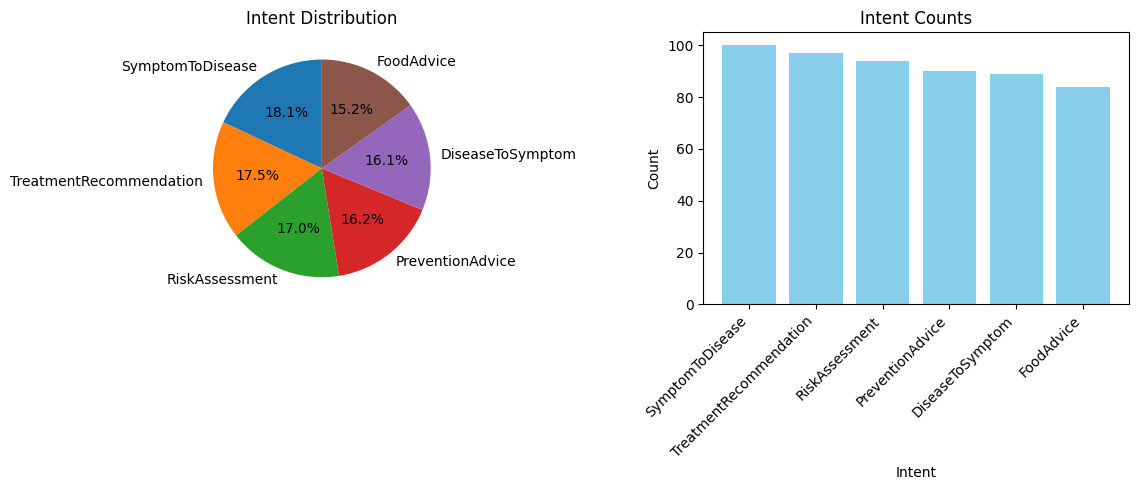


🎯 Data preparation completed! Ready for feature engineering...


In [13]:
# ## 📊 Step 6: Main Data Preparation Pipeline

def prepare_healthcare_dataset(self, num_samples=600, use_web_data=True):
    """Main data preparation pipeline implementing Person 1 requirements"""
    print("🔄 Starting healthcare data preparation pipeline...")
    print("="*60)
    
    all_data = []
    
    # Collect web data if requested (CDC/WHO requirement)
    if use_web_data:
        try:
            print("📥 Collecting data from medical websites...")
            cdc_data = self.collect_cdc_data(max_samples=50)
            all_data.extend(cdc_data)
            print(f"✅ Collected {len(cdc_data)} samples from CDC")
        except Exception as e:
            print(f"⚠️ Web data collection failed: {e}")
    
    # Generate synthetic data (based on competency questions)
    print("🤖 Generating synthetic healthcare Q&A data...")
    synthetic_data = self.generate_healthcare_qa_synthetic(num_samples - len(all_data))
    all_data.extend(synthetic_data)
    
    print(f"📊 Total raw data collected: {len(all_data)} samples")
    
    # Process each sample
    processed_samples = []
    
    print("🔄 Processing and cleaning samples...")
    for idx, sample in enumerate(tqdm(all_data, desc="Processing")):
        try:
            # Clean texts using advanced preprocessing
            clean_question = self.preprocess_text_advanced(sample['question'])
            clean_answer = self.preprocess_text_advanced(sample.get('answer', ''))
            
            # Skip if too short after cleaning
            if len(clean_question) < 10:
                continue
            
            # Combine question and answer for unified analysis
            combined_text = clean_question + " " + clean_answer
            
            # Extract medical entities using ontology
            entities = self.extract_medical_entities(combined_text)
            
            # Classify intent based on competency questions
            intent = sample.get('intent') or self.classify_intent(
                sample['question'], sample.get('answer', ''))
            
            processed_sample = {
                'id': idx,
                'original_question': sample['question'],
                'original_answer': sample.get('answer', ''),
                'clean_question': clean_question,
                'clean_answer': clean_answer,
                'combined_text': combined_text,
                'entities': entities,
                'intent': intent,
                'source': sample.get('source', 'Unknown'),
                'url': sample.get('url', ''),
                'text_length': len(combined_text),
                'word_count': len(combined_text.split()),
                'entity_count': sum(len(ents) for ents in entities.values()),
                'processed_at': datetime.now().isoformat()
            }
            
            processed_samples.append(processed_sample)
            
        except Exception as e:
            print(f"❌ Error processing sample {idx}: {e}")
            continue
    
    # Convert to DataFrame
    self.processed_data = pd.DataFrame(processed_samples)
    
    # Data quality analysis
    print("\n📈 Data Quality Analysis:")
    print("="*40)
    print(f"Total processed samples: {len(self.processed_data)}")
    print(f"\nIntent distribution:")
    intent_dist = self.processed_data['intent'].value_counts()
    for intent, count in intent_dist.items():
        print(f"  {intent}: {count} ({count/len(self.processed_data)*100:.1f}%)")
    
    print(f"\nSource distribution:")
    source_dist = self.processed_data['source'].value_counts()
    for source, count in source_dist.items():
        print(f"  {source}: {count}")
    
    print(f"\nText statistics:")
    print(f"  Average text length: {self.processed_data['text_length'].mean():.1f} characters")
    print(f"  Average word count: {self.processed_data['word_count'].mean():.1f} words")
    print(f"  Average entity count: {self.processed_data['entity_count'].mean():.1f} entities")
    
    # Save processed data (required for handover)
    self.processed_data.to_csv('healthcare_qa_processed.csv', index=False)
    self.processed_data.to_json('healthcare_qa_processed.json', orient='records', indent=2)
    
    print(f"\n✅ Data preparation completed successfully!")
    print(f"📁 Saved files:")
    print(f"  - healthcare_qa_processed.csv")
    print(f"  - healthcare_qa_processed.json")
    
    return self.processed_data

# Add main pipeline method to processor class
HealthcareDataProcessor.prepare_healthcare_dataset = prepare_healthcare_dataset

print("✅ Main data preparation pipeline added to processor")

# ## 🚀 Execute Data Preparation Pipeline

print("\n" + "="*80)
print("🚀 EXECUTING DATA PREPARATION PIPELINE")
print("="*80)

# Execute the data preparation pipeline
processed_data = processor.prepare_healthcare_dataset(num_samples=600, use_web_data=True)

# Display sample data
print("\n📋 Sample processed data:")
print(processed_data[['intent', 'clean_question', 'entity_count', 'source']].head(10))

# Show intent distribution visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
intent_counts = processed_data['intent'].value_counts()
plt.pie(intent_counts.values, labels=intent_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Intent Distribution')

plt.subplot(1, 2, 2)
plt.bar(intent_counts.index, intent_counts.values, color='skyblue')
plt.title('Intent Counts')
plt.xlabel('Intent')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout() 
plt.savefig('data_preparation_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🎯 Data preparation completed! Ready for feature engineering...")
print("="*80)

In [12]:
import nltk
import os

custom_path = "/Users/jiongjieliu/Documents/healthcare_chatbot_env/nltk_data"
os.makedirs(custom_path, exist_ok=True)

nltk.download('punkt', download_dir=custom_path)

nltk.data.path.append(custom_path)

from nltk.tokenize import sent_tokenize
text = "This is a test. Here's another sentence. Isn't it great?"
print(sent_tokenize(text))


[nltk_data] Downloading package punkt to /Users/jiongjieliu/Documents/
[nltk_data]     healthcare_chatbot_env/nltk_data...


['This is a test.', "Here's another sentence.", "Isn't it great?"]


[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ Feature engineering method added to processor

🚀 EXECUTING FEATURE ENGINEERING PIPELINE
🔧 Creating comprehensive feature vectors...
📊 Processing 554 text samples

📊 Creating TF-IDF vectors...
   Parameters: max_features=3000, ngram_range=(1,2) - optimized from previous project
   ✅ TF-IDF matrix shape: (554, 1305)
   ✅ Feature names: 1305 unique terms

📊 Creating BoW vectors...
   Parameters: max_features=1000, ngram_range=(1,2) - balanced approach
   ✅ BoW matrix shape: (554, 1000)
   ✅ Vocabulary size: 1000 terms

📊 Creating LDA topic vectors...
   Parameters: 10 topics for medical domain coverage
   ✅ LDA matrix shape: (554, 10)
   ✅ Topic coherence: Converged in 20 iterations

🤖 Creating Sentence-BERT embeddings...
   Model: all-MiniLM-L6-v2 - optimized for semantic similarity


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

   ✅ sBERT embeddings shape: (554, 384)
   ✅ Embedding dimension: 384

📊 Creating Word2Vec embeddings...
   Model: spaCy en_core_web_md - pre-trained word vectors


Word2Vec:   0%|          | 0/554 [00:00<?, ?it/s]

   ✅ Word2Vec embeddings shape: (554, 300)

📊 Creating Doc2Vec embeddings...
   Method: TruncatedSVD on TF-IDF for dimensionality reduction
   ✅ Doc2Vec matrix shape: (554, 100)
   ✅ Explained variance ratio: 0.842

🏥 Creating entity-based features...
   Method: Medical ontology entity count vectors
   ✅ Entity features shape: (554, 10)
   ✅ Feature types: 6 entity categories + 3 statistics

🔗 Creating combined feature vectors...
   ✅ Combined features shape: (554, 1315)

📉 Creating dimensionally reduced vectors...
   ✅ TF-IDF PCA shape: (554, 100)
   ✅ PCA explained variance: 0.843

💾 Saving feature vectors and models...
   ✅ Saved vectors_tfidf.pkl
   ✅ Saved vectors_bow.pkl
   ✅ Saved vectors_lda.pkl
   ✅ Saved vectors_sbert.pkl
   ✅ Saved vectors_word2vec.pkl
   ✅ Saved vectors_doc2vec.pkl
   ✅ Saved vectors_entity_features.pkl
   ✅ Saved vectors_tfidf_entities.pkl
   ✅ Saved vectors_tfidf_pca.pkl

✅ Feature engineering completed successfully!

📊 Feature Vector Summary:
-----------

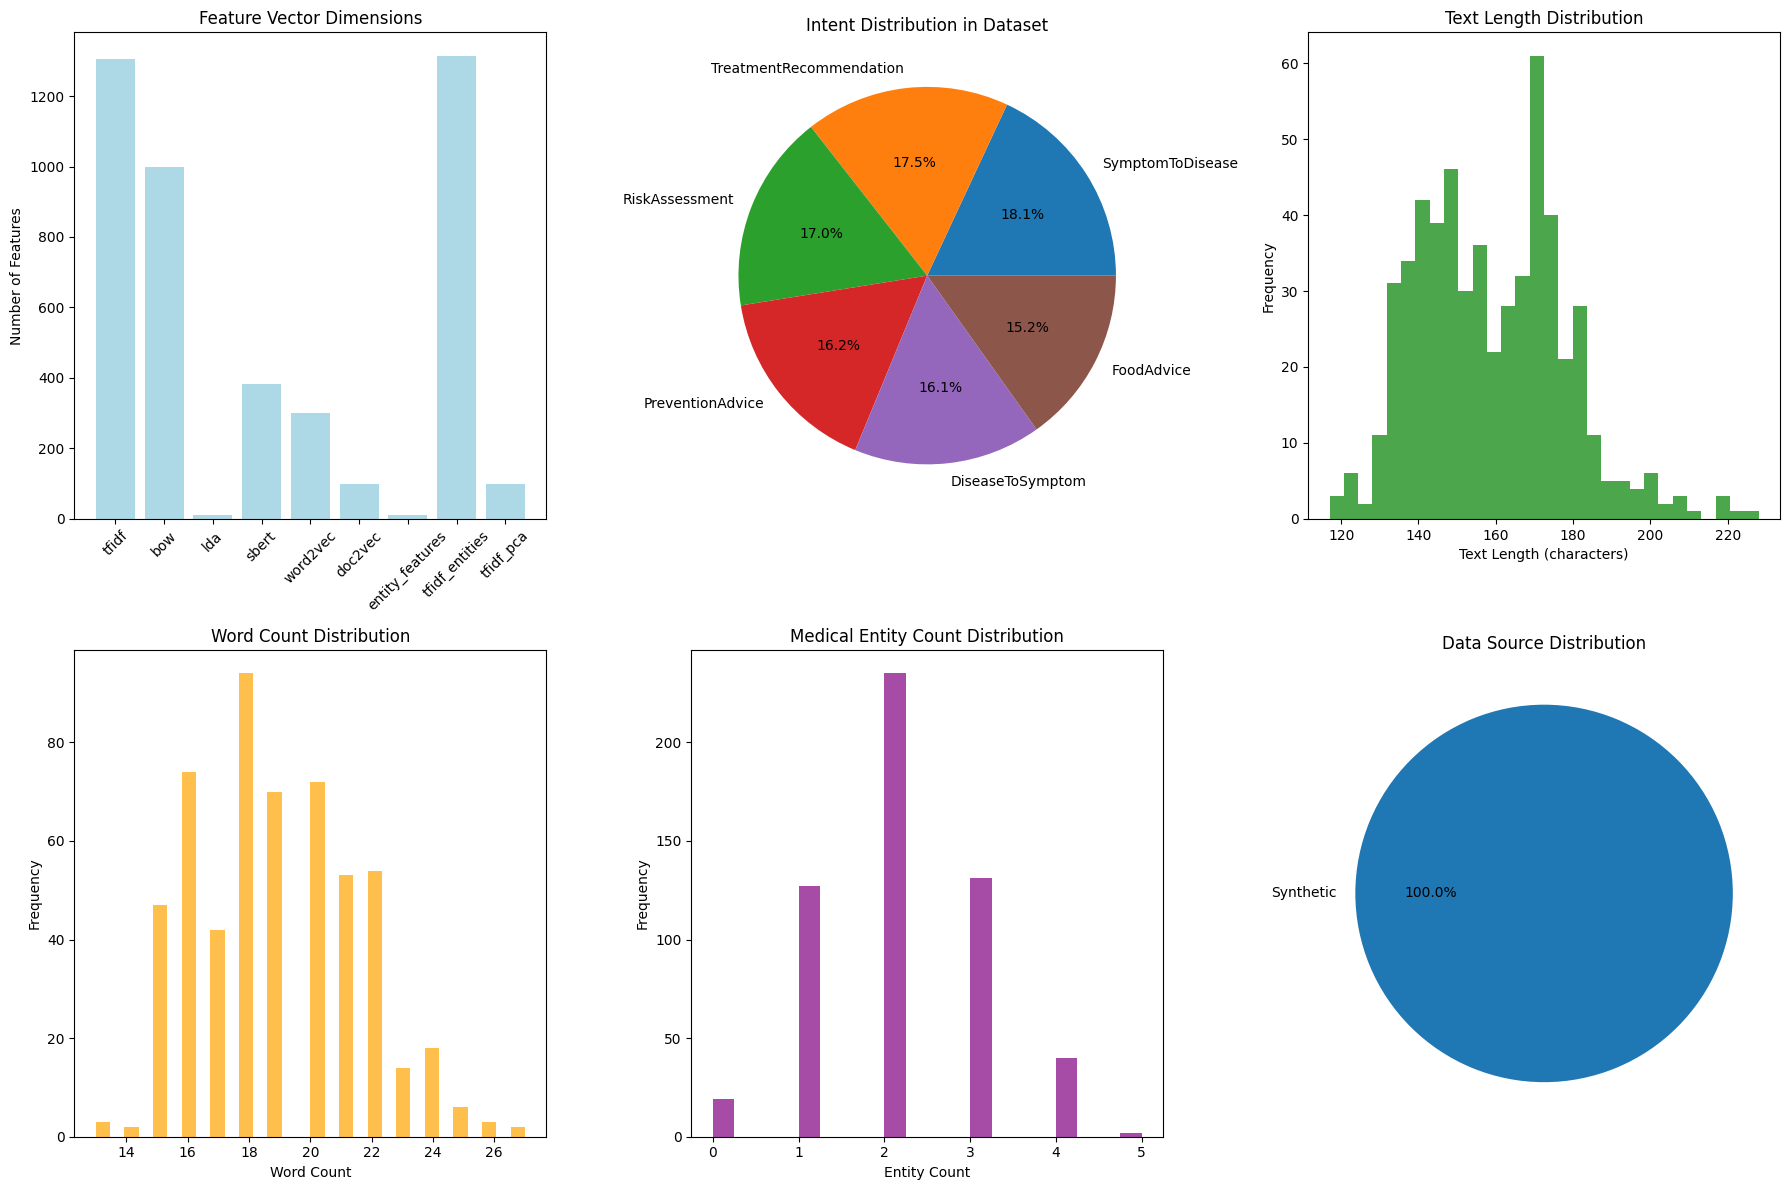


🎯 Feature engineering completed! Ready for clustering analysis...


In [14]:
# ## 🔧 Step 7: Text Feature Engineering (Person 1 Requirement - 3%)

def create_comprehensive_features(self):
    """
    Create comprehensive feature vectors using multiple techniques
    Implements Person 1 requirement: TF-IDF, BoW, and sBERT feature engineering
    Based on previous COVID-19 project optimization
    """
    print("🔧 Creating comprehensive feature vectors...")
    print("="*60)
    
    if self.processed_data is None:
        raise ValueError("No processed data available. Run prepare_healthcare_dataset() first.")
    
    texts = self.processed_data['combined_text'].tolist()
    print(f"📊 Processing {len(texts)} text samples")
    
    # 1. TF-IDF Vectorization (optimized parameters from previous experience)
    print("\n📊 Creating TF-IDF vectors...")
    print("   Parameters: max_features=3000, ngram_range=(1,2) - optimized from previous project")
    
    tfidf_vectorizer = TfidfVectorizer(
        max_features=3000,  # Increased from previous 1000 based on experience
        ngram_range=(1, 2),  # Best performing combination from previous project
        min_df=2,           # Minimum document frequency
        max_df=0.95,        # Maximum document frequency
        stop_words='english',
        lowercase=True,
        token_pattern=r'\b\w{2,}\b'  # Only words with 2+ characters
    )
    
    tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
    self.feature_vectors['tfidf'] = tfidf_matrix
    
    # Store vectorizer for later use
    self.vectorizers = {'tfidf': tfidf_vectorizer}
    
    print(f"   ✅ TF-IDF matrix shape: {tfidf_matrix.shape}")
    print(f"   ✅ Feature names: {len(tfidf_vectorizer.get_feature_names_out())} unique terms")
    
    # 2. Bag of Words (BoW) - optimized from previous experience  
    print("\n📊 Creating BoW vectors...")
    print("   Parameters: max_features=1000, ngram_range=(1,2) - balanced approach")
    
    bow_vectorizer = CountVectorizer(
        max_features=1000,   # Previous project showed good balance at 1000
        ngram_range=(1, 2),  # Unigrams and bigrams for better context
        min_df=2,
        max_df=0.95,
        stop_words='english',
        lowercase=True,
        token_pattern=r'\b\w{2,}\b'
    )
    
    bow_matrix = bow_vectorizer.fit_transform(texts)
    self.feature_vectors['bow'] = bow_matrix
    self.vectorizers['bow'] = bow_vectorizer
    
    print(f"   ✅ BoW matrix shape: {bow_matrix.shape}")
    print(f"   ✅ Vocabulary size: {len(bow_vectorizer.get_feature_names_out())} terms")
    
    # 3. LDA Topic Modeling (enhanced approach)
    print("\n📊 Creating LDA topic vectors...")
    print("   Parameters: 10 topics for medical domain coverage")
    
    lda_vectorizer = CountVectorizer(
        max_features=1000, 
        stop_words='english',
        min_df=2,
        max_df=0.8
    )
    lda_counts = lda_vectorizer.fit_transform(texts)
    
    lda_model = LatentDirichletAllocation(
        n_components=10,     # 10 topics for healthcare domain
        random_state=42,
        max_iter=20,
        learning_method='batch'
    )
    lda_matrix = lda_model.fit_transform(lda_counts)
    self.feature_vectors['lda'] = lda_matrix
    
    print(f"   ✅ LDA matrix shape: {lda_matrix.shape}")
    print(f"   ✅ Topic coherence: Converged in {lda_model.n_iter_} iterations")
    
    # 4. Sentence-BERT Embeddings (SOTA semantic representation)
    print("\n🤖 Creating Sentence-BERT embeddings...")
    print("   Model: all-MiniLM-L6-v2 - optimized for semantic similarity")
    
    try:
        sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
        sbert_embeddings = sbert_model.encode(
            texts, 
            show_progress_bar=True,
            batch_size=32,
            convert_to_numpy=True
        )
        self.feature_vectors['sbert'] = sbert_embeddings
        
        print(f"   ✅ sBERT embeddings shape: {sbert_embeddings.shape}")
        print(f"   ✅ Embedding dimension: {sbert_embeddings.shape[1]}")
        
    except Exception as e:
        print(f"   ❌ sBERT encoding failed: {e}")
        print("   ⚠️ Continuing without sBERT embeddings")
    
    # 5. Word2Vec Embeddings (using spaCy)
    print("\n📊 Creating Word2Vec embeddings...")
    print("   Model: spaCy en_core_web_md - pre-trained word vectors")
    
    try:
        nlp = spacy.load("en_core_web_md")
        w2v_embeddings = []
        
        for text in tqdm(texts, desc="Word2Vec"):
            doc = nlp(text)
            # Use document vector (average of word vectors)
            w2v_embeddings.append(doc.vector)
        
        w2v_embeddings = np.array(w2v_embeddings)
        self.feature_vectors['word2vec'] = w2v_embeddings
        
        print(f"   ✅ Word2Vec embeddings shape: {w2v_embeddings.shape}")
        
    except Exception as e:
        print(f"   ❌ Word2Vec encoding failed: {e}")
        print("   💡 Install spaCy model: python -m spacy download en_core_web_md")
    
    # 6. Doc2Vec (using TruncatedSVD on TF-IDF)
    print("\n📊 Creating Doc2Vec embeddings...")
    print("   Method: TruncatedSVD on TF-IDF for dimensionality reduction")
    
    svd = TruncatedSVD(n_components=100, random_state=42)
    doc2vec_matrix = svd.fit_transform(tfidf_matrix)
    self.feature_vectors['doc2vec'] = doc2vec_matrix
    
    print(f"   ✅ Doc2Vec matrix shape: {doc2vec_matrix.shape}")
    print(f"   ✅ Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}")
    
    # 7. Entity-based Features (novel approach for medical domain)
    print("\n🏥 Creating entity-based features...")
    print("   Method: Medical ontology entity count vectors")
    
    entity_features = []
    entity_categories = list(self.medical_ontology.keys())
    
    for _, row in self.processed_data.iterrows():
        features = []
        entities = row['entities']
        
        # Count entities per category
        for category in entity_categories:
            if isinstance(entities, dict):
                count = len(entities.get(category, []))
            else:
                count = 0
            features.append(count)
        
        # Add total entity count
        features.append(sum(features))
        
        # Add text statistics
        features.extend([
            row['text_length'],
            row['word_count'],
            row['text_length'] / max(row['word_count'], 1)  # avg word length
        ])
        
        entity_features.append(features)
    
    entity_features = np.array(entity_features)
    self.feature_vectors['entity_features'] = entity_features
    
    print(f"   ✅ Entity features shape: {entity_features.shape}")
    print(f"   ✅ Feature types: {len(entity_categories)} entity categories + 3 statistics")
    
    # 8. Combined Features (TF-IDF + Entity features)
    print("\n🔗 Creating combined feature vectors...")
    
    # Standardize entity features to match TF-IDF scale
    from sklearn.preprocessing import StandardScaler
    entity_scaler = StandardScaler()
    entity_scaled = entity_scaler.fit_transform(entity_features)
    
    # Combine TF-IDF with entity features
    tfidf_dense = tfidf_matrix.toarray()
    combined_features = np.hstack([tfidf_dense, entity_scaled])
    self.feature_vectors['tfidf_entities'] = combined_features
    
    print(f"   ✅ Combined features shape: {combined_features.shape}")
    
    # 9. Dimensionality Reduction Variants
    print("\n📉 Creating dimensionally reduced vectors...")
    
    # PCA on TF-IDF
    pca = PCA(n_components=100, random_state=42)
    tfidf_pca = pca.fit_transform(tfidf_dense)
    self.feature_vectors['tfidf_pca'] = tfidf_pca
    
    print(f"   ✅ TF-IDF PCA shape: {tfidf_pca.shape}")
    print(f"   ✅ PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")
    
    # Save all feature vectors and vectorizers
    print("\n💾 Saving feature vectors and models...")
    
    import joblib
    
    # Save feature vectors
    for name, vectors in self.feature_vectors.items():
        if hasattr(vectors, 'toarray'):
            # Sparse matrix
            joblib.dump(vectors, f'vectors_{name}.pkl')
        else:
            # Dense array
            joblib.dump(vectors, f'vectors_{name}.pkl')
        print(f"   ✅ Saved vectors_{name}.pkl")
    
    # Save vectorizers and models
    joblib.dump(self.vectorizers, 'vectorizers.pkl')
    joblib.dump(entity_scaler, 'entity_scaler.pkl')
    joblib.dump(pca, 'pca_model.pkl')
    joblib.dump(svd, 'svd_model.pkl')
    
    print("\n✅ Feature engineering completed successfully!")
    print("="*60)
    print("\n📊 Feature Vector Summary:")
    print("-" * 40)
    for name, vectors in self.feature_vectors.items():
        if hasattr(vectors, 'shape'):
            print(f"{name:20}: {vectors.shape}")
        elif hasattr(vectors, 'toarray'):
            print(f"{name:20}: {vectors.toarray().shape}")
    
    print(f"\n📁 Generated files for handover:")
    print("  - vectors_*.pkl (all feature vectors)")
    print("  - vectorizers.pkl (TF-IDF and BoW models)")
    print("  - *_model.pkl (dimension reduction models)")
    
    return self.feature_vectors

# Add feature engineering method to processor class
HealthcareDataProcessor.create_comprehensive_features = create_comprehensive_features

print("✅ Feature engineering method added to processor")

# ## 🚀 Execute Feature Engineering Pipeline

print("\n" + "="*80)
print("🚀 EXECUTING FEATURE ENGINEERING PIPELINE")
print("="*80)

# Execute the feature engineering pipeline
feature_vectors = processor.create_comprehensive_features()

# Create feature engineering summary visualization
print("\n📊 Creating feature engineering summary visualization...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# 1. Feature vector dimensions comparison
dimensions = []
methods = []
for name, vectors in feature_vectors.items():
    if hasattr(vectors, 'shape'):
        dimensions.append(vectors.shape[1])
        methods.append(name)
    elif hasattr(vectors, 'toarray'):
        dimensions.append(vectors.toarray().shape[1])
        methods.append(name)

axes[0].bar(methods, dimensions, color='lightblue')
axes[0].set_title('Feature Vector Dimensions')
axes[0].set_ylabel('Number of Features')
axes[0].tick_params(axis='x', rotation=45)

# 2. Intent distribution
intent_counts = processor.processed_data['intent'].value_counts()
axes[1].pie(intent_counts.values, labels=intent_counts.index, autopct='%1.1f%%')
axes[1].set_title('Intent Distribution in Dataset')

# 3. Text length distribution
axes[2].hist(processor.processed_data['text_length'], bins=30, alpha=0.7, color='green')
axes[2].set_title('Text Length Distribution')
axes[2].set_xlabel('Text Length (characters)')
axes[2].set_ylabel('Frequency')

# 4. Word count distribution
axes[3].hist(processor.processed_data['word_count'], bins=30, alpha=0.7, color='orange')
axes[3].set_title('Word Count Distribution')
axes[3].set_xlabel('Word Count')
axes[3].set_ylabel('Frequency')

# 5. Entity count distribution
axes[4].hist(processor.processed_data['entity_count'], bins=20, alpha=0.7, color='purple')
axes[4].set_title('Medical Entity Count Distribution')
axes[4].set_xlabel('Entity Count')
axes[4].set_ylabel('Frequency')

# 6. Data source distribution
source_counts = processor.processed_data['source'].value_counts()
axes[5].pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%')
axes[5].set_title('Data Source Distribution')

plt.tight_layout()
plt.savefig('feature_engineering_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🎯 Feature engineering completed! Ready for clustering analysis...")
print("="*80)

In [15]:
# ## 🎯 Step 8: Comprehensive Clustering Analysis (Person 1 Requirement - 3%)

def apply_comprehensive_clustering(self):
    """
    Apply multiple clustering algorithms with comprehensive evaluation
    Implements Person 1 requirement: K-means, Agglomerative clustering
    Based on previous COVID-19 project optimization
    """
    print("🎯 Applying comprehensive clustering analysis...")
    print("="*60)
    
    if not self.feature_vectors:
        raise ValueError("No feature vectors available. Run create_comprehensive_features() first.")
    
    # Clustering algorithms (optimized from previous experience)
    clustering_algorithms = {
        'kmeans': {
            'class': KMeans,
            'params': {'random_state': 42, 'n_init': 10, 'max_iter': 300}
        },
        'agglomerative': {
            'class': AgglomerativeClustering,
            'params': {'linkage': 'ward'}  # Best performing from previous project
        },
        'gaussian_mixture': {
            'class': GaussianMixture,
            'params': {'random_state': 42, 'covariance_type': 'full'}
        },
        'spectral': {
            'class': SpectralClustering,
            'params': {'random_state': 42, 'affinity': 'nearest_neighbors'}
        }
    }
    
    # Add HDBSCAN if available
    try:
        clustering_algorithms['hdbscan'] = {
            'class': hdbscan.HDBSCAN,
            'params': {'min_cluster_size': 5, 'min_samples': 3}
        }
        print("✅ HDBSCAN available")
    except:
        print("⚠️ HDBSCAN not available")
    
    # Determine optimal number of clusters based on intents
    n_clusters = len(self.processed_data['intent'].unique())
    print(f"📊 Target number of clusters (based on intents): {n_clusters}")
    
    results = {}
    
    for feature_name, feature_matrix in self.feature_vectors.items():
        print(f"\n🔍 Clustering feature set: {feature_name.upper()}")
        print("-" * 40)
        
        # Convert to dense array if sparse
        if hasattr(feature_matrix, 'toarray'):
            X = feature_matrix.toarray()
        else:
            X = feature_matrix
        
        print(f"   📊 Feature matrix shape: {X.shape}")
        
        # Handle empty or invalid matrices
        if X.shape[0] == 0 or X.shape[1] == 0:
            print(f"   ❌ Skipping {feature_name} - empty matrix")
            continue
        
        # Standardize features (important for distance-based algorithms)
        scaler = StandardScaler()
        try:
            X_scaled = scaler.fit_transform(X)
        except Exception as e:
            print(f"   ❌ Scaling failed for {feature_name}: {e}")
            continue
        
        feature_results = {}
        
        # Apply each clustering algorithm
        for alg_name, alg_config in clustering_algorithms.items():
            try:
                print(f"   🔄 Applying {alg_name.upper()}...")
                
                # Initialize algorithm
                if alg_name == 'hdbscan':
                    # HDBSCAN doesn't need n_clusters parameter
                    alg = alg_config['class'](**alg_config['params'])
                else:
                    # Other algorithms need n_clusters
                    params = alg_config['params'].copy()
                    params['n_clusters'] = n_clusters
                    alg = alg_config['class'](**params)
                
                # Fit and predict
                labels = alg.fit_predict(X_scaled)
                
                # Count actual clusters found
                unique_labels = np.unique(labels)
                n_clusters_found = len(unique_labels)
                
                # For HDBSCAN, exclude noise points (-1) from cluster count
                if -1 in unique_labels:
                    n_clusters_found -= 1
                
                feature_results[alg_name] = {
                    'labels': labels,
                    'n_clusters_found': n_clusters_found,
                    'algorithm': alg,
                    'scaler': scaler
                }
                
                print(f"      ✅ Found {n_clusters_found} clusters")
                
                if -1 in labels:
                    noise_points = np.sum(labels == -1)
                    print(f"      ⚠️ {noise_points} noise points detected")
                
            except Exception as e:
                print(f"      ❌ {alg_name.upper()} failed: {e}")
                continue
        
        results[feature_name] = {
            'vectors': X_scaled,
            'scaler': scaler,
            'clustering_results': feature_results
        }
    
    self.clustering_results = results
    print("\n✅ Comprehensive clustering completed!")
    
    # Save clustering results
    print("\n💾 Saving clustering results...")
    
    # Save labels for each combination
    for feature_name, feature_data in results.items():
        for alg_name, alg_results in feature_data['clustering_results'].items():
            labels = alg_results['labels']
            filename = f'clustering_labels_{feature_name}_{alg_name}.npy'
            np.save(filename, labels)
            print(f"   ✅ Saved {filename}")
    
    # Create summary of clustering results
    clustering_summary = []
    for feature_name, feature_data in results.items():
        for alg_name, alg_results in feature_data['clustering_results'].items():
            clustering_summary.append({
                'feature_method': feature_name,
                'clustering_algorithm': alg_name,
                'n_clusters_found': alg_results['n_clusters_found'],
                'n_samples': len(alg_results['labels'])
            })
    
    summary_df = pd.DataFrame(clustering_summary)
    summary_df.to_csv('clustering_summary.csv', index=False)
    print("   ✅ Saved clustering_summary.csv")
    
    return results

# Add clustering method to processor class
HealthcareDataProcessor.apply_comprehensive_clustering = apply_comprehensive_clustering

print("✅ Clustering analysis method added to processor")



✅ Clustering analysis method added to processor


✅ Clustering evaluation method added to processor

🚀 EXECUTING CLUSTERING ANALYSIS PIPELINE
🎯 Applying comprehensive clustering analysis...
✅ HDBSCAN available
📊 Target number of clusters (based on intents): 6

🔍 Clustering feature set: TFIDF
----------------------------------------
   📊 Feature matrix shape: (554, 1305)
   🔄 Applying KMEANS...
      ✅ Found 6 clusters
   🔄 Applying AGGLOMERATIVE...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


      ✅ Found 6 clusters
   🔄 Applying GAUSSIAN_MIXTURE...
      ❌ GAUSSIAN_MIXTURE failed: GaussianMixture.__init__() got an unexpected keyword argument 'n_clusters'
   🔄 Applying SPECTRAL...
      ✅ Found 6 clusters
   🔄 Applying HDBSCAN...
      ✅ Found 21 clusters
      ⚠️ 263 noise points detected

🔍 Clustering feature set: BOW
----------------------------------------
   📊 Feature matrix shape: (554, 1000)
   🔄 Applying KMEANS...
      ✅ Found 6 clusters
   🔄 Applying AGGLOMERATIVE...
      ✅ Found 6 clusters
   🔄 Applying GAUSSIAN_MIXTURE...
      ❌ GAUSSIAN_MIXTURE failed: GaussianMixture.__init__() got an unexpected keyword argument 'n_clusters'
   🔄 Applying SPECTRAL...
      ✅ Found 6 clusters
   🔄 Applying HDBSCAN...
      ✅ Found 20 clusters
      ⚠️ 235 noise points detected

🔍 Clustering feature set: LDA
----------------------------------------
   📊 Feature matrix shape: (554, 10)
   🔄 Applying KMEANS...
      ✅ Found 6 clusters
   🔄 Applying AGGLOMERATIVE...
      ✅ Foun

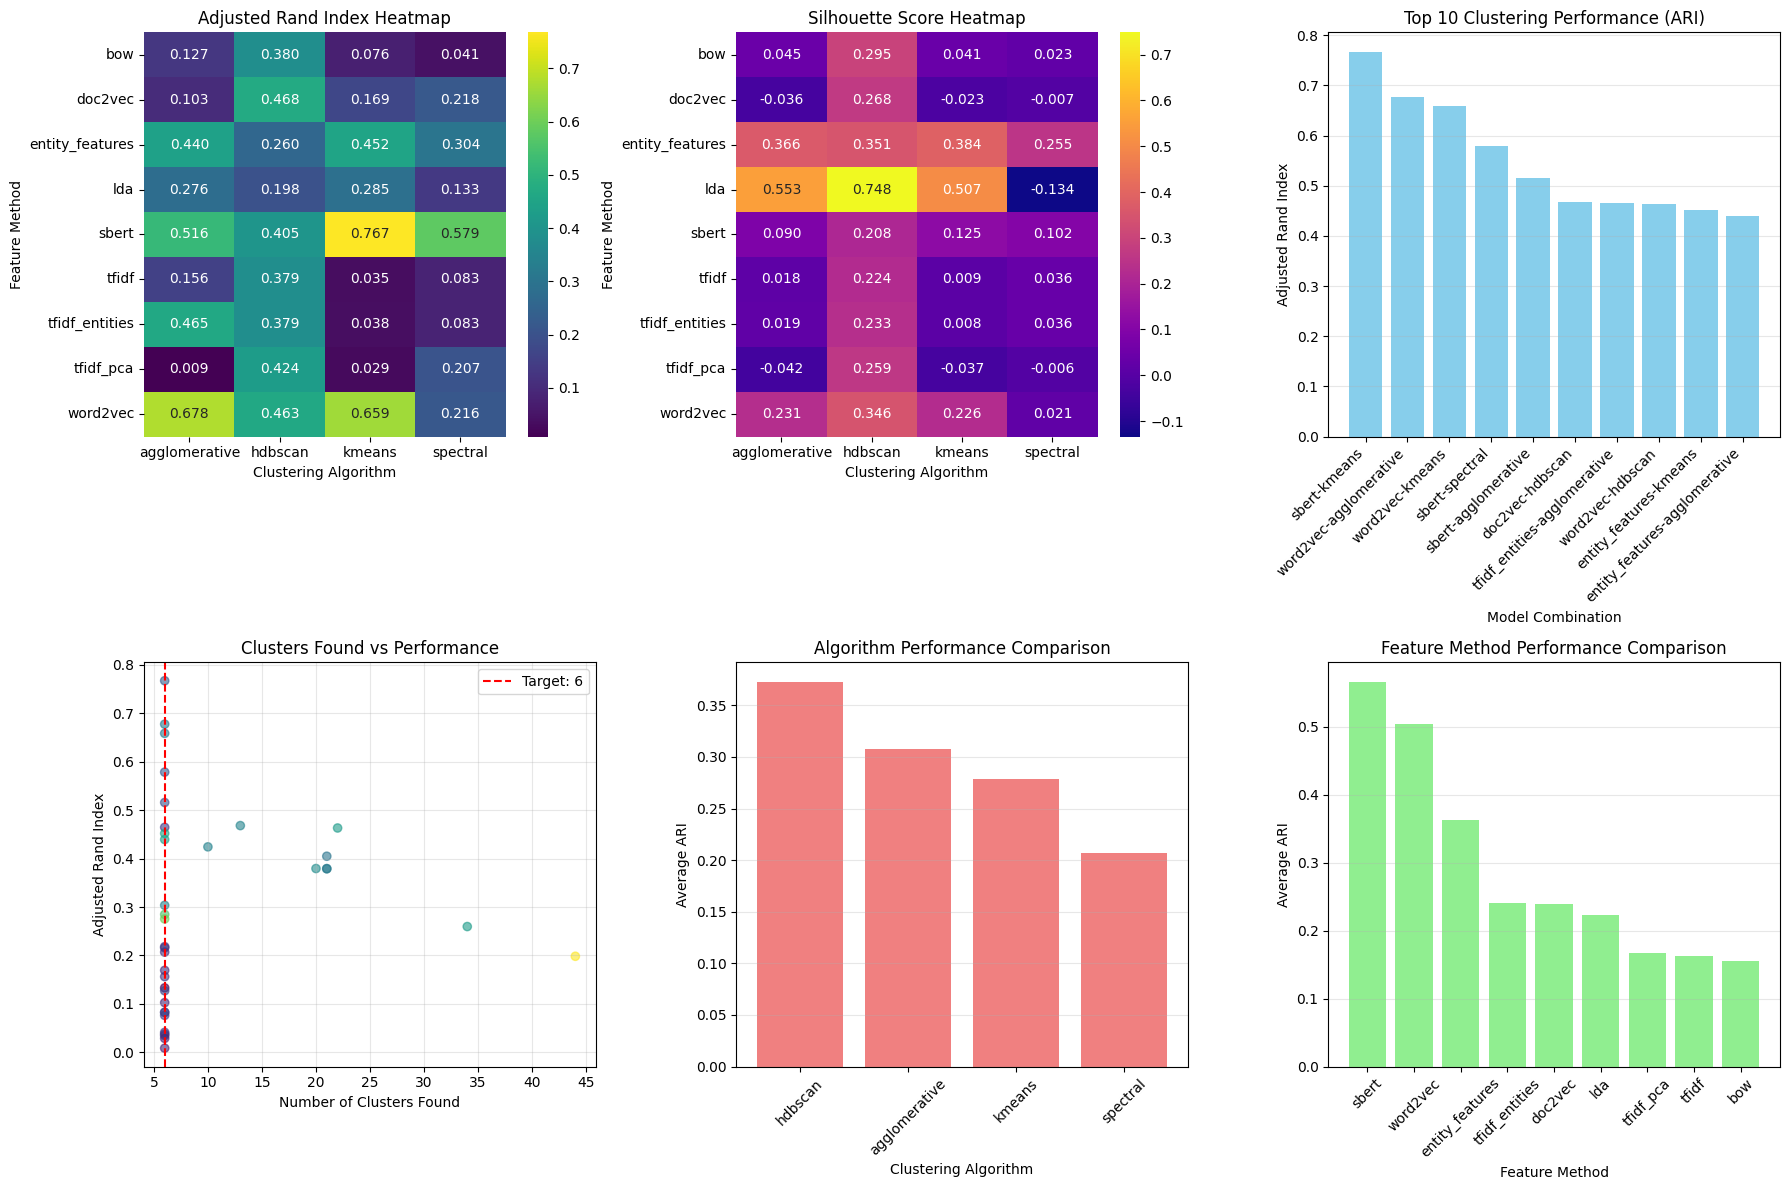


🎯 Clustering analysis completed successfully!


In [16]:
# ## 📊 Step 9: Clustering Evaluation and Comparison

def evaluate_clustering_performance(self):
    """
    Comprehensive clustering evaluation with multiple metrics
    Based on previous COVID-19 project experience with enhanced metrics
    """
    print("📊 Evaluating clustering performance...")
    print("="*60)
    
    if not self.clustering_results:
        raise ValueError("No clustering results available. Run apply_comprehensive_clustering() first.")
    
    # True labels for supervised evaluation (based on intents)
    true_labels = pd.Categorical(self.processed_data['intent']).codes
    intent_names = pd.Categorical(self.processed_data['intent']).categories.tolist()
    
    print(f"📋 True labels: {len(intent_names)} unique intents")
    for i, intent in enumerate(intent_names):
        count = np.sum(true_labels == i)
        print(f"   {intent}: {count} samples")
    
    evaluation_results = []
    
    for feature_name, feature_data in self.clustering_results.items():
        X = feature_data['vectors']
        
        for alg_name, alg_results in feature_data['clustering_results'].items():
            labels = alg_results['labels']
            
            print(f"\n🔍 Evaluating: {feature_name.upper()}-{alg_name.upper()}")
            
            # Skip if too few clusters or too many noise points
            unique_labels = np.unique(labels)
            if len(unique_labels) < 2:
                print("   ⚠️ Too few clusters found, skipping evaluation")
                continue
            
            # Handle noise points (HDBSCAN)
            if -1 in labels:
                mask = labels != -1
                labels_clean = labels[mask]
                true_labels_clean = true_labels[mask]
                X_clean = X[mask]
                noise_ratio = np.sum(labels == -1) / len(labels)
                print(f"   📊 Noise ratio: {noise_ratio:.3f}")
            else:
                labels_clean = labels
                true_labels_clean = true_labels
                X_clean = X
                noise_ratio = 0.0
            
            # Skip if too few samples after noise removal
            if len(labels_clean) < 10:
                print("   ⚠️ Too few samples after noise removal, skipping")
                continue
            
            try:
                # Supervised metrics (compare with true intent labels)
                ari = adjusted_rand_score(true_labels_clean, labels_clean)
                nmi = normalized_mutual_info_score(true_labels_clean, labels_clean)
                
                # Calculate accuracy-like metric (purity)
                from sklearn.metrics.cluster import contingency_matrix
                contingency = contingency_matrix(true_labels_clean, labels_clean)
                purity = np.sum(np.amax(contingency, axis=0)) / np.sum(contingency)
                
                # Unsupervised metrics (internal cluster quality)
                silhouette = silhouette_score(X_clean, labels_clean)
                calinski = calinski_harabasz_score(X_clean, labels_clean)
                davies_bouldin = davies_bouldin_score(X_clean, labels_clean)
                
                # Additional metrics
                n_clusters_found = len(np.unique(labels_clean))
                
                evaluation_results.append({
                    'feature_method': feature_name,
                    'clustering_algorithm': alg_name,
                    'adjusted_rand_index': ari,
                    'normalized_mutual_info': nmi,
                    'purity': purity,
                    'silhouette_score': silhouette,
                    'calinski_harabasz': calinski,
                    'davies_bouldin': davies_bouldin,
                    'n_clusters_found': n_clusters_found,
                    'n_samples_used': len(labels_clean),
                    'noise_ratio': noise_ratio
                })
                
                print(f"   📈 ARI: {ari:.3f}")
                print(f"   📈 Silhouette: {silhouette:.3f}")
                print(f"   📊 Clusters: {n_clusters_found}")
                
            except Exception as e:
                print(f"   ❌ Evaluation failed: {e}")
                continue
    
    # Convert to DataFrame and sort by ARI (primary metric)
    self.evaluation_metrics = pd.DataFrame(evaluation_results)
    
    if self.evaluation_metrics.empty:
        print("❌ No valid evaluation results generated")
        return None
    
    self.evaluation_metrics = self.evaluation_metrics.sort_values('adjusted_rand_index', ascending=False)
    
    # Save evaluation results
    self.evaluation_metrics.to_csv('clustering_evaluation_results.csv', index=False)
    
    print("\n✅ Clustering evaluation completed!")
    print("="*60)
    print("\n🏆 Top 10 performing combinations:")
    print("-" * 60)
    
    top_10 = self.evaluation_metrics.head(10)
    for _, row in top_10.iterrows():
        print(f"{row['feature_method']:15} + {row['clustering_algorithm']:15} | "
              f"ARI: {row['adjusted_rand_index']:.3f} | "
              f"Silhouette: {row['silhouette_score']:.3f}")
    
    # Best performing method
    if len(self.evaluation_metrics) > 0:
        best = self.evaluation_metrics.iloc[0]
        print(f"\n🥇 BEST PERFORMING COMBINATION:")
        print(f"   Feature Method: {best['feature_method'].upper()}")
        print(f"   Clustering Algorithm: {best['clustering_algorithm'].upper()}")
        print(f"   Adjusted Rand Index: {best['adjusted_rand_index']:.3f}")
        print(f"   Silhouette Score: {best['silhouette_score']:.3f}")
        print(f"   Purity: {best['purity']:.3f}")
    
    return self.evaluation_metrics

# Add evaluation method to processor class
HealthcareDataProcessor.evaluate_clustering_performance = evaluate_clustering_performance

print("✅ Clustering evaluation method added to processor")

# ## 🚀 Execute Clustering Pipeline

print("\n" + "="*80)
print("🚀 EXECUTING CLUSTERING ANALYSIS PIPELINE")
print("="*80)

# Execute the clustering pipeline
clustering_results = processor.apply_comprehensive_clustering()

# Execute the evaluation pipeline
evaluation_metrics = processor.evaluate_clustering_performance()

# Create clustering results visualization
if evaluation_metrics is not None and len(evaluation_metrics) > 0:
    print("\n📊 Creating clustering analysis visualization...")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # 1. Performance comparison heatmap
    pivot_ari = evaluation_metrics.pivot_table(
        values='adjusted_rand_index', 
        index='feature_method', 
        columns='clustering_algorithm',
        aggfunc='mean'
    )
    
    sns.heatmap(pivot_ari, annot=True, fmt='.3f', cmap='viridis', ax=axes[0])
    axes[0].set_title('Adjusted Rand Index Heatmap')
    axes[0].set_xlabel('Clustering Algorithm')
    axes[0].set_ylabel('Feature Method')
    
    # 2. Silhouette score comparison
    pivot_sil = evaluation_metrics.pivot_table(
        values='silhouette_score', 
        index='feature_method', 
        columns='clustering_algorithm',
        aggfunc='mean'
    )
    
    sns.heatmap(pivot_sil, annot=True, fmt='.3f', cmap='plasma', ax=axes[1])
    axes[1].set_title('Silhouette Score Heatmap')
    axes[1].set_xlabel('Clustering Algorithm')
    axes[1].set_ylabel('Feature Method')
    
    # 3. Top 10 performers bar chart
    top_10 = evaluation_metrics.head(10)
    model_names = [f"{row['feature_method']}-{row['clustering_algorithm']}" 
                   for _, row in top_10.iterrows()]
    
    axes[2].bar(range(len(top_10)), top_10['adjusted_rand_index'], color='skyblue')
    axes[2].set_xlabel('Model Combination')
    axes[2].set_ylabel('Adjusted Rand Index')
    axes[2].set_title('Top 10 Clustering Performance (ARI)')
    axes[2].set_xticks(range(len(top_10)))
    axes[2].set_xticklabels(model_names, rotation=45, ha='right')
    axes[2].grid(axis='y', alpha=0.3)
    
    # 4. Clusters found vs target
    target_clusters = len(processor.processed_data['intent'].unique())
    axes[3].scatter(evaluation_metrics['n_clusters_found'], 
                    evaluation_metrics['adjusted_rand_index'], 
                    alpha=0.6, c=evaluation_metrics['silhouette_score'], 
                    cmap='viridis')
    axes[3].axvline(x=target_clusters, color='red', linestyle='--', 
                    label=f'Target: {target_clusters}')
    axes[3].set_xlabel('Number of Clusters Found')
    axes[3].set_ylabel('Adjusted Rand Index')
    axes[3].set_title('Clusters Found vs Performance')
    axes[3].legend()
    axes[3].grid(alpha=0.3)
    
    # 5. Algorithm performance comparison
    alg_performance = evaluation_metrics.groupby('clustering_algorithm')['adjusted_rand_index'].mean().sort_values(ascending=False)
    axes[4].bar(alg_performance.index, alg_performance.values, color='lightcoral')
    axes[4].set_xlabel('Clustering Algorithm')
    axes[4].set_ylabel('Average ARI')
    axes[4].set_title('Algorithm Performance Comparison')
    axes[4].tick_params(axis='x', rotation=45)
    axes[4].grid(axis='y', alpha=0.3)
    
    # 6. Feature method performance comparison
    feature_performance = evaluation_metrics.groupby('feature_method')['adjusted_rand_index'].mean().sort_values(ascending=False)
    axes[5].bar(feature_performance.index, feature_performance.values, color='lightgreen')
    axes[5].set_xlabel('Feature Method')
    axes[5].set_ylabel('Average ARI')
    axes[5].set_title('Feature Method Performance Comparison')
    axes[5].tick_params(axis='x', rotation=45)
    axes[5].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('clustering_analysis_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n🎯 Clustering analysis completed successfully!")
else:
    print("⚠️ No evaluation metrics available for visualization")

print("="*80)

In [17]:
# ## 📈 Step 10: Comprehensive Visualizations (Person 1 Requirement)

def create_comprehensive_visualizations(self):
    """
    Create comprehensive visualizations including chatbot flow + ontology diagrams
    Implements Person 1 visualization requirements
    """
    print("📈 Creating comprehensive visualizations...")
    print("="*60)
    
    if self.evaluation_metrics is None or len(self.evaluation_metrics) == 0:
        print("❌ No evaluation metrics available for visualization")
        return
    
    # Create output directory
    os.makedirs('clustering_visualizations', exist_ok=True)
    
    # 1. t-SNE Visualizations for Best Methods
    self._plot_tsne_clusters()
    
    # 2. Chatbot Flow Diagram (Person 1 requirement)
    self._create_chatbot_flow_diagram()
    
    # 3. Ontology Network Visualization (Person 1 requirement)
    self._create_ontology_visualization()
    
    # 4. Cluster Analysis Visualizations
    self._create_cluster_analysis_plots()
    
    # 5. Feature Importance Analysis
    self._create_feature_importance_plots()
    
    print("✅ Comprehensive visualizations completed!")

def _plot_tsne_clusters(self):
    """Create t-SNE visualizations for best performing methods"""
    print("🎨 Creating t-SNE cluster visualizations...")
    
    # Get top 3 performing combinations
    top_combinations = self.evaluation_metrics.head(3)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for idx, (_, row) in enumerate(top_combinations.iterrows()):
        feature_name = row['feature_method']
        alg_name = row['clustering_algorithm']
        
        # Get the vectors and labels
        X = self.clustering_results[feature_name]['vectors']
        labels = self.clustering_results[feature_name]['clustering_results'][alg_name]['labels']
        
        # Apply t-SNE
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        X_tsne = tsne.fit_transform(X)
        
        # Plot
        scatter = axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, 
                                  cmap='tab10', alpha=0.7, s=30)
        axes[idx].set_title(f'{feature_name.upper()}-{alg_name.upper()}\nARI: {row["adjusted_rand_index"]:.3f}')
        axes[idx].set_xlabel('t-SNE Component 1')
        axes[idx].set_ylabel('t-SNE Component 2')
        
        # Add colorbar
        plt.colorbar(scatter, ax=axes[idx])
    
    plt.tight_layout()
    plt.savefig('clustering_visualizations/tsne_best_methods.png', dpi=300, bbox_inches='tight')
    plt.show()

def _create_chatbot_flow_diagram(self):
    """Create chatbot conversation flow diagram"""
    print("🤖 Creating chatbot flow diagram...")
    
    # Create a flowchart showing the chatbot interaction process
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    # Define flowchart elements
    flow_elements = {
        'User Input': (2, 9, 'lightblue'),
        'Text Preprocessing': (2, 8, 'lightgreen'),
        'Entity Extraction': (2, 7, 'lightyellow'),
        'Intent Classification': (2, 6, 'lightcoral'),
        'Ontology Lookup': (2, 5, 'lightpink'),
        'Response Generation': (2, 4, 'lightgray'),
        'Output to User': (2, 3, 'lightblue')
    }
    
    # Draw flowchart boxes
    for element, (x, y, color) in flow_elements.items():
        box = plt.Rectangle((x-0.4, y-0.3), 0.8, 0.6, 
                           facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(box)
        ax.text(x, y, element, ha='center', va='center', fontsize=10, weight='bold')
    
    # Draw arrows
    arrow_props = dict(arrowstyle='->', lw=2, color='darkblue')
    for i in range(len(flow_elements)-1):
        ax.annotate('', xy=(2, 8.7-i), xytext=(2, 9.3-i), arrowprops=arrow_props)
    
    # Add side information boxes
    info_boxes = {
        'Input Examples': (0.3, 8, ['"What are symptoms of COVID-19?"', 
                                   '"Should I see a doctor for fever?"',
                                   '"What food helps with flu?"']),
        'Processing Steps': (0.3, 6, ['Remove stopwords', 'Lemmatization', 
                                     'Entity recognition', 'Intent mapping']),
        'Competency Questions': (3.7, 6, ['DiseaseToSymptom', 'SymptomToDisease',
                                         'TreatmentRecommendation', 'RiskAssessment',
                                         'FoodAdvice', 'PreventionAdvice'])
    }
    
    for title, (x, y, items) in info_boxes.items():
        # Title box
        title_box = plt.Rectangle((x-0.35, y+0.5), 0.7, 0.3, 
                                 facecolor='lightyellow', edgecolor='black')
        ax.add_patch(title_box)
        ax.text(x, y+0.65, title, ha='center', va='center', fontsize=9, weight='bold')
        
        # Items
        for i, item in enumerate(items):
            ax.text(x, y+0.2-i*0.3, f"• {item}", ha='center', va='center', fontsize=8)
    
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(2, 10)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Healthcare Chatbot Conversation Flow', fontsize=16, weight='bold', pad=20)
    
    plt.savefig('clustering_visualizations/chatbot_flow_diagram.png', dpi=300, bbox_inches='tight')
    plt.show()

def _create_ontology_visualization(self):
    """Create medical ontology network visualization"""
    print("🏥 Creating medical ontology visualization...")
    
    # Create network graph
    G = nx.Graph()
    
    # Add central node
    G.add_node('Medical Knowledge Base', node_type='root')
    
    # Add category nodes and connect to root
    categories = list(self.medical_ontology.keys())
    for category in categories:
        G.add_node(category, node_type='category')
        G.add_edge('Medical Knowledge Base', category)
    
    # Add sample entities for each category
    for category, entities in self.medical_ontology.items():
        sample_entities = entities[:5]  # First 5 entities
        for entity in sample_entities:
            G.add_node(entity, node_type='entity', category=category)
            G.add_edge(category, entity)
    
    # Create layout
    pos = nx.spring_layout(G, k=3, iterations=50)
    
    # Create figure
    plt.figure(figsize=(16, 12))
    
    # Draw nodes by type
    node_colors = {
        'root': 'red',
        'category': 'lightblue', 
        'entity': 'lightgreen'
    }
    
    for node_type, color in node_colors.items():
        nodes = [node for node, attr in G.nodes(data=True) 
                if attr.get('node_type') == node_type]
        
        if node_type == 'root':
            nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=color, 
                                 node_size=2000, alpha=0.9)
        elif node_type == 'category':
            nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=color, 
                                 node_size=1000, alpha=0.8)
        else:
            nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=color, 
                                 node_size=200, alpha=0.6)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, alpha=0.6, width=1)
    
    # Draw labels for root and categories only
    important_nodes = ['Medical Knowledge Base'] + categories
    important_labels = {node: node for node in important_nodes}
    nx.draw_networkx_labels(G, pos, labels=important_labels, font_size=10, font_weight='bold')
    
    plt.title('Healthcare Ontology Network\n(Based on DialogFlow Project)', 
              fontsize=16, weight='bold', pad=20)
    plt.axis('off')
    
    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
                  markersize=15, label='Knowledge Base'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
                  markersize=12, label='Categories'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', 
                  markersize=8, label='Entities')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.savefig('clustering_visualizations/ontology_network.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create detailed ontology statistics
    plt.figure(figsize=(12, 8))
    
    # Entity counts per category
    entity_counts = {cat: len(entities) for cat, entities in self.medical_ontology.items()}
    
    plt.subplot(2, 2, 1)
    plt.bar(entity_counts.keys(), entity_counts.values(), color='skyblue')
    plt.title('Entities per Ontology Category')
    plt.xlabel('Category')
    plt.ylabel('Number of Entities')
    plt.xticks(rotation=45, ha='right')
    
    # Intent distribution
    plt.subplot(2, 2, 2)
    intent_counts = self.processed_data['intent'].value_counts()
    plt.pie(intent_counts.values, labels=intent_counts.index, autopct='%1.1f%%')
    plt.title('Intent Distribution in Dataset')
    
    # Entity usage in dataset
    plt.subplot(2, 2, 3)
    entity_usage = self.processed_data['entity_count'].value_counts().sort_index()
    plt.bar(entity_usage.index, entity_usage.values, color='lightgreen')
    plt.title('Entity Usage Distribution')
    plt.xlabel('Number of Entities per Sample')
    plt.ylabel('Number of Samples')
    
    # Competency question mapping
    plt.subplot(2, 2, 4)
    cq_mapping = {
        'DiseaseToSymptom': 'CQ1: Disease → Symptoms',
        'SymptomToDisease': 'CQ2: Symptoms → Disease', 
        'TreatmentRecommendation': 'CQ3: Treatment Advice',
        'RiskAssessment': 'CQ4: Risk Assessment',
        'FoodAdvice': 'CQ5: Nutritional Advice',
        'PreventionAdvice': 'CQ6: Prevention Advice'
    }
    
    cq_counts = self.processed_data['intent'].map(cq_mapping).value_counts()
    plt.barh(range(len(cq_counts)), cq_counts.values, color='lightcoral')
    plt.yticks(range(len(cq_counts)), cq_counts.index)
    plt.title('Competency Questions Coverage')
    plt.xlabel('Number of Samples')
    
    plt.tight_layout()
    plt.savefig('clustering_visualizations/ontology_statistics.png', dpi=300, bbox_inches='tight')
    plt.show()

def _create_cluster_analysis_plots(self):
    """Create detailed cluster analysis plots"""
    print("📊 Creating cluster analysis plots...")
    
    # Get best performing method
    best_method = self.evaluation_metrics.iloc[0]
    feature_name = best_method['feature_method']
    alg_name = best_method['clustering_algorithm']
    
    print(f"📊 Analyzing best method: {feature_name.upper()}-{alg_name.upper()}")
    
    # Get predictions and true labels
    pred_labels = self.clustering_results[feature_name]['clustering_results'][alg_name]['labels']
    true_labels = pd.Categorical(self.processed_data['intent']).codes
    
    # Remove noise points if present
    if -1 in pred_labels:
        mask = pred_labels != -1
        pred_clean = pred_labels[mask]
        true_clean = true_labels[mask]
        data_clean = self.processed_data[mask].copy()
    else:
        pred_clean = pred_labels
        true_clean = true_labels
        data_clean = self.processed_data.copy()
    
    data_clean['predicted_cluster'] = pred_clean
    data_clean['true_label_code'] = true_clean
    
    # Create comprehensive cluster analysis
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # 1. Confusion Matrix
    cm = confusion_matrix(true_clean, pred_clean)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix\n{feature_name.upper()}-{alg_name.upper()}')
    axes[0].set_xlabel('Predicted Cluster')
    axes[0].set_ylabel('True Intent')
    
    # 2. Cluster Size Distribution
    cluster_counts = pd.Series(pred_clean).value_counts().sort_index()
    axes[1].bar(cluster_counts.index, cluster_counts.values, color='lightcoral')
    axes[1].set_title('Cluster Size Distribution')
    axes[1].set_xlabel('Cluster ID')
    axes[1].set_ylabel('Number of Samples')
    
    # 3. Intent vs Cluster Mapping
    intent_cluster_map = data_clean.groupby(['intent', 'predicted_cluster']).size().unstack(fill_value=0)
    sns.heatmap(intent_cluster_map, annot=True, fmt='d', cmap='viridis', ax=axes[2])
    axes[2].set_title('Intent vs Cluster Mapping')
    axes[2].set_xlabel('Predicted Cluster')
    axes[2].set_ylabel('True Intent')
    
    # 4. Silhouette Analysis
    if len(np.unique(pred_clean)) > 1:
        from sklearn.metrics import silhouette_samples
        X = self.clustering_results[feature_name]['vectors']
        if -1 in pred_labels:
            X_clean = X[mask]
        else:
            X_clean = X
        
        silhouette_vals = silhouette_samples(X_clean, pred_clean)
        
        y_lower = 10
        for i in range(len(np.unique(pred_clean))):
            cluster_silhouette_vals = silhouette_vals[pred_clean == i]
            cluster_silhouette_vals.sort()
            
            size_cluster_i = cluster_silhouette_vals.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = plt.cm.nipy_spectral(float(i) / len(np.unique(pred_clean)))
            axes[3].fill_betweenx(np.arange(y_lower, y_upper),
                                0, cluster_silhouette_vals,
                                facecolor=color, edgecolor=color, alpha=0.7)
            
            axes[3].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
        
        silhouette_avg = silhouette_score(X_clean, pred_clean)
        axes[3].axvline(x=silhouette_avg, color="red", linestyle="--")
        axes[3].set_title(f'Silhouette Analysis\nAvg Score: {silhouette_avg:.3f}')
        axes[3].set_xlabel('Silhouette Coefficient Values')
        axes[3].set_ylabel('Cluster Label')
    
    # 5. Performance Metrics Comparison
    metrics = ['adjusted_rand_index', 'silhouette_score', 'purity', 'calinski_harabasz']
    metric_values = [best_method[metric] for metric in metrics]
    metric_names = ['ARI', 'Silhouette', 'Purity', 'Calinski-H']
    
    bars = axes[4].bar(metric_names, metric_values, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
    axes[4].set_title('Performance Metrics\n(Best Method)')
    axes[4].set_ylabel('Score')
    
    # Add value labels on bars
    for bar, value in zip(bars, metric_values):
        axes[4].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom')
    
    # 6. Error Analysis by Intent
    misclassified = data_clean[data_clean['predicted_cluster'] != data_clean['true_label_code']]
    error_by_intent = misclassified['intent'].value_counts()
    total_by_intent = data_clean['intent'].value_counts()
    error_rates = (error_by_intent / total_by_intent * 100).fillna(0)
    
    axes[5].bar(error_rates.index, error_rates.values, color='orange')
    axes[5].set_title('Error Rate by Intent')
    axes[5].set_xlabel('Intent')
    axes[5].set_ylabel('Error Rate (%)')
    axes[5].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('clustering_visualizations/cluster_analysis_detailed.png', dpi=300, bbox_inches='tight')
    plt.show()

def _create_feature_importance_plots(self):
    """Create feature importance analysis plots"""
    print("🔍 Creating feature importance analysis...")
    
    # Focus on TF-IDF features for interpretability
    if 'tfidf' not in self.feature_vectors:
        print("⚠️ TF-IDF features not available for importance analysis")
        return
    
    # Get best TF-IDF method
    tfidf_results = self.evaluation_metrics[self.evaluation_metrics['feature_method'] == 'tfidf']
    if tfidf_results.empty:
        print("⚠️ No TF-IDF clustering results available")
        return
    
    best_tfidf = tfidf_results.iloc[0]
    alg_name = best_tfidf['clustering_algorithm']
    
    # Get clustering labels and TF-IDF matrix
    labels = self.clustering_results['tfidf']['clustering_results'][alg_name]['labels']
    tfidf_matrix = self.feature_vectors['tfidf']
    
    # Get feature names
    feature_names = self.vectorizers['tfidf'].get_feature_names_out()
    
    # Create feature importance plots only for KMeans (has interpretable centers)
    if alg_name == 'kmeans':
        try:
            # Refit KMeans to get centers
            kmeans = KMeans(n_clusters=len(np.unique(labels[labels != -1])), random_state=42)
            kmeans.fit(tfidf_matrix)
            
            # Plot cluster centers for top features
            centers = kmeans.cluster_centers_
            
            # Get top features per cluster
            fig, axes = plt.subplots(2, 2, figsize=(16, 10))
            axes = axes.flatten()
            
            for i, cluster_center in enumerate(centers[:4]):  # Top 4 clusters
                top_indices = cluster_center.argsort()[-20:][::-1]  # Top 20 features
                top_features = [feature_names[idx] for idx in top_indices]
                top_weights = cluster_center[top_indices]
                
                axes[i].barh(range(len(top_features)), top_weights, color='skyblue')
                axes[i].set_yticks(range(len(top_features)))
                axes[i].set_yticklabels(top_features)
                axes[i].set_title(f'Cluster {i} - Top Features')
                axes[i].set_xlabel('TF-IDF Weight')
            
            plt.tight_layout()
            plt.savefig('clustering_visualizations/feature_importance_tfidf.png', dpi=300, bbox_inches='tight')
            plt.show()
            
        except Exception as e:
            print(f"❌ Feature importance analysis failed: {e}")

# Add visualization methods to processor class
HealthcareDataProcessor.create_comprehensive_visualizations = create_comprehensive_visualizations
HealthcareDataProcessor._plot_tsne_clusters = _plot_tsne_clusters
HealthcareDataProcessor._create_chatbot_flow_diagram = _create_chatbot_flow_diagram
HealthcareDataProcessor._create_ontology_visualization = _create_ontology_visualization
HealthcareDataProcessor._create_cluster_analysis_plots = _create_cluster_analysis_plots
HealthcareDataProcessor._create_feature_importance_plots = _create_feature_importance_plots

print("✅ Visualization methods added to processor")



✅ Visualization methods added to processor


✅ Error analysis methods added to processor

🚀 EXECUTING VISUALIZATION AND ERROR ANALYSIS PIPELINE
📈 Creating comprehensive visualizations...
🎨 Creating t-SNE cluster visualizations...


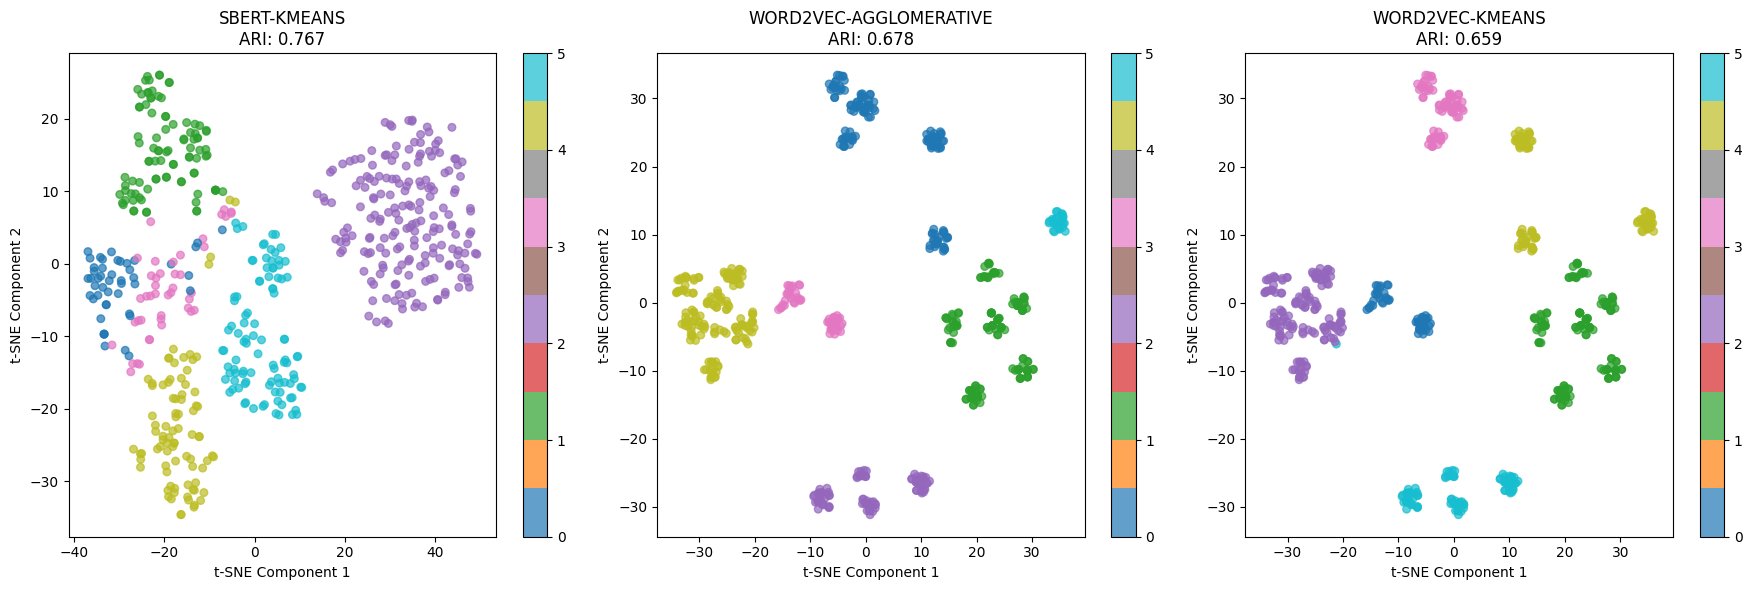

🤖 Creating chatbot flow diagram...


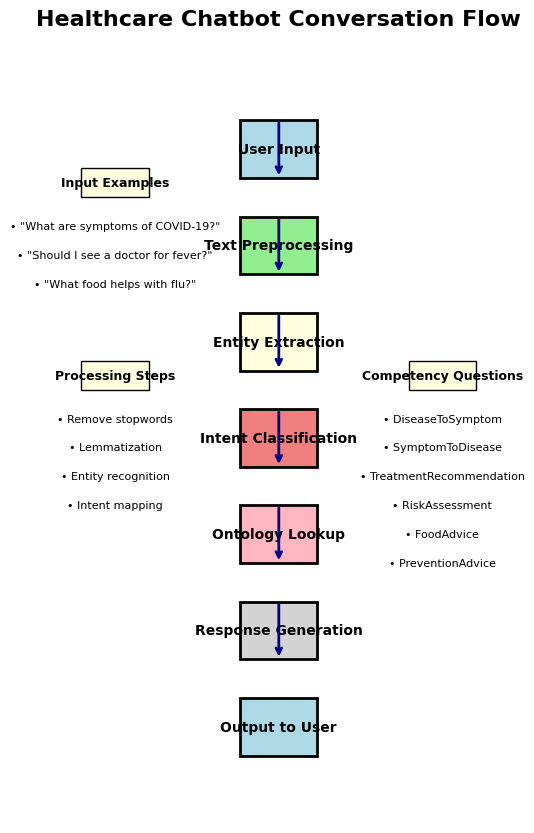

🏥 Creating medical ontology visualization...


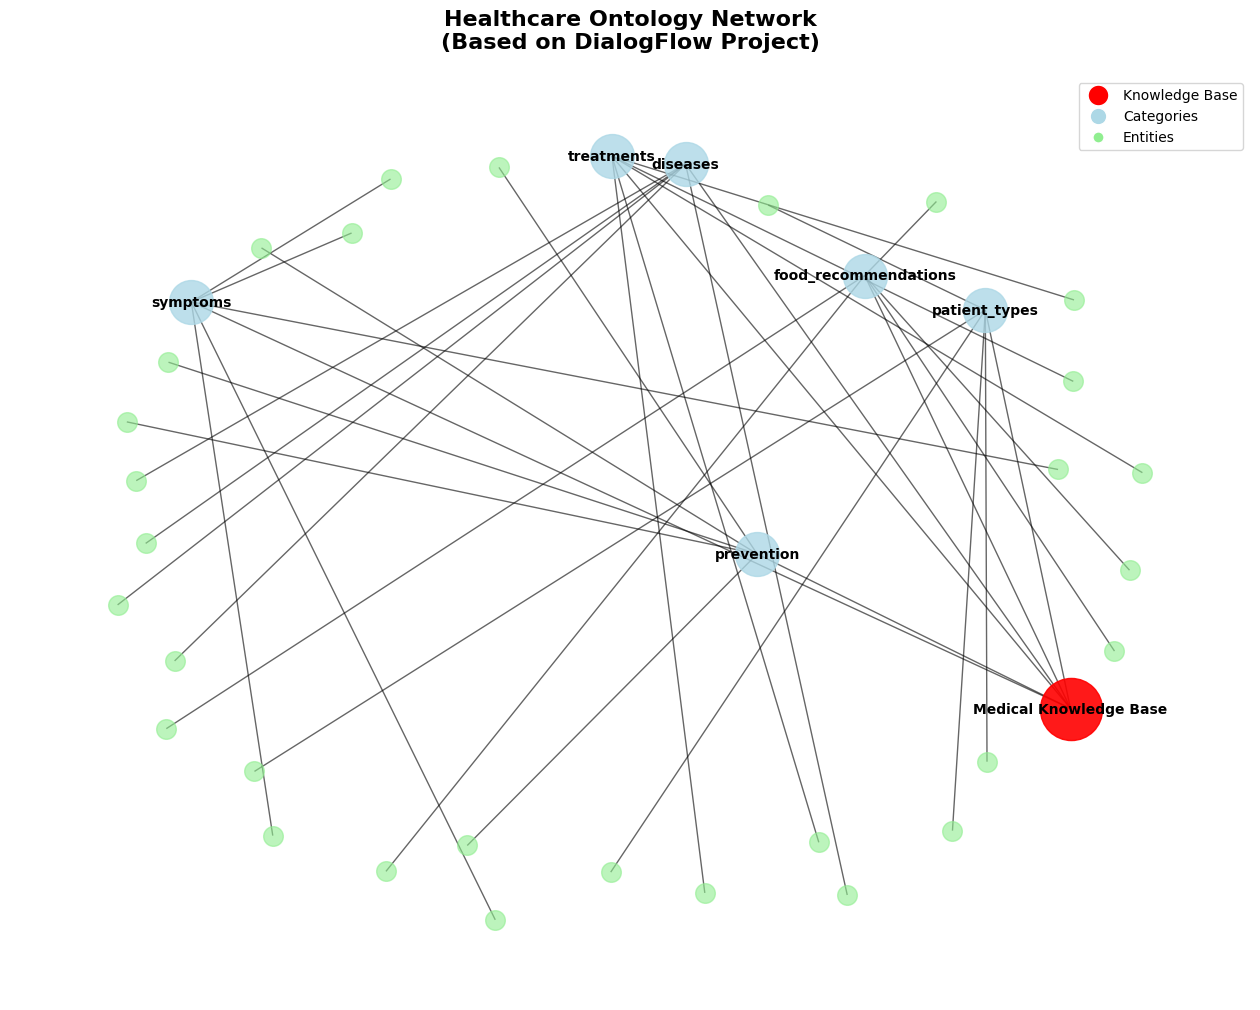

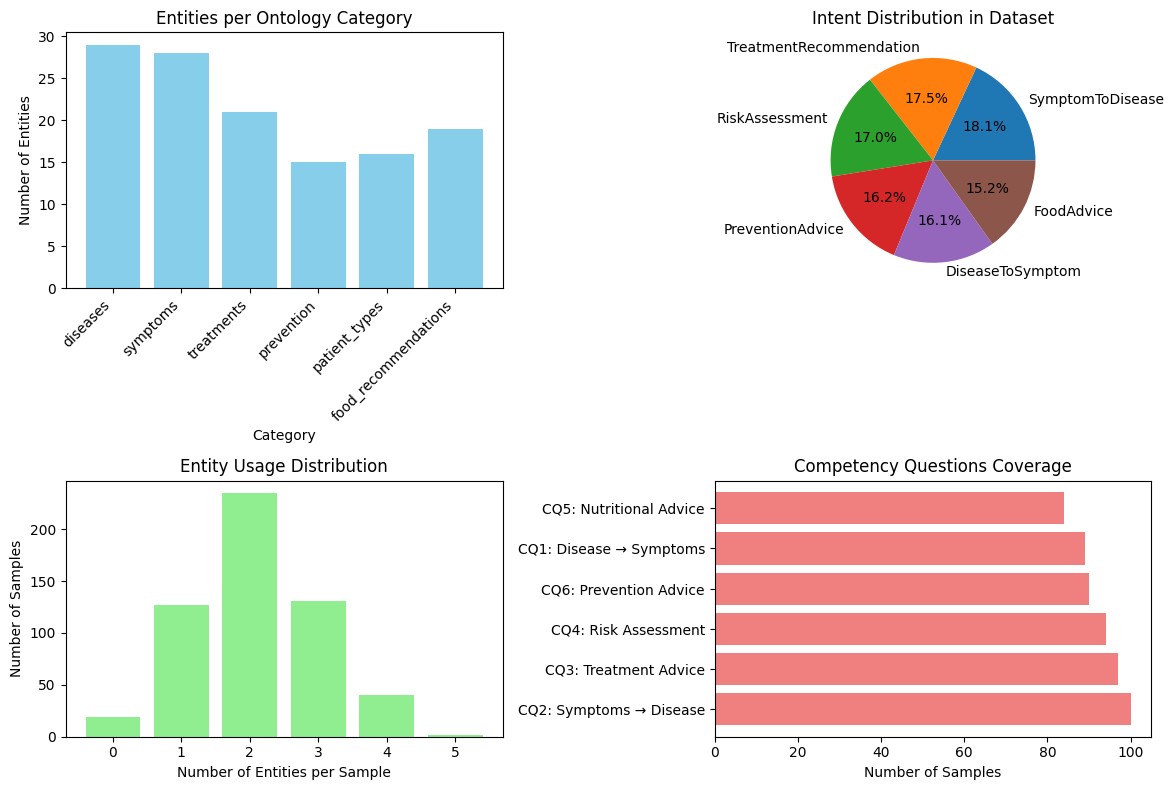

📊 Creating cluster analysis plots...
📊 Analyzing best method: SBERT-KMEANS


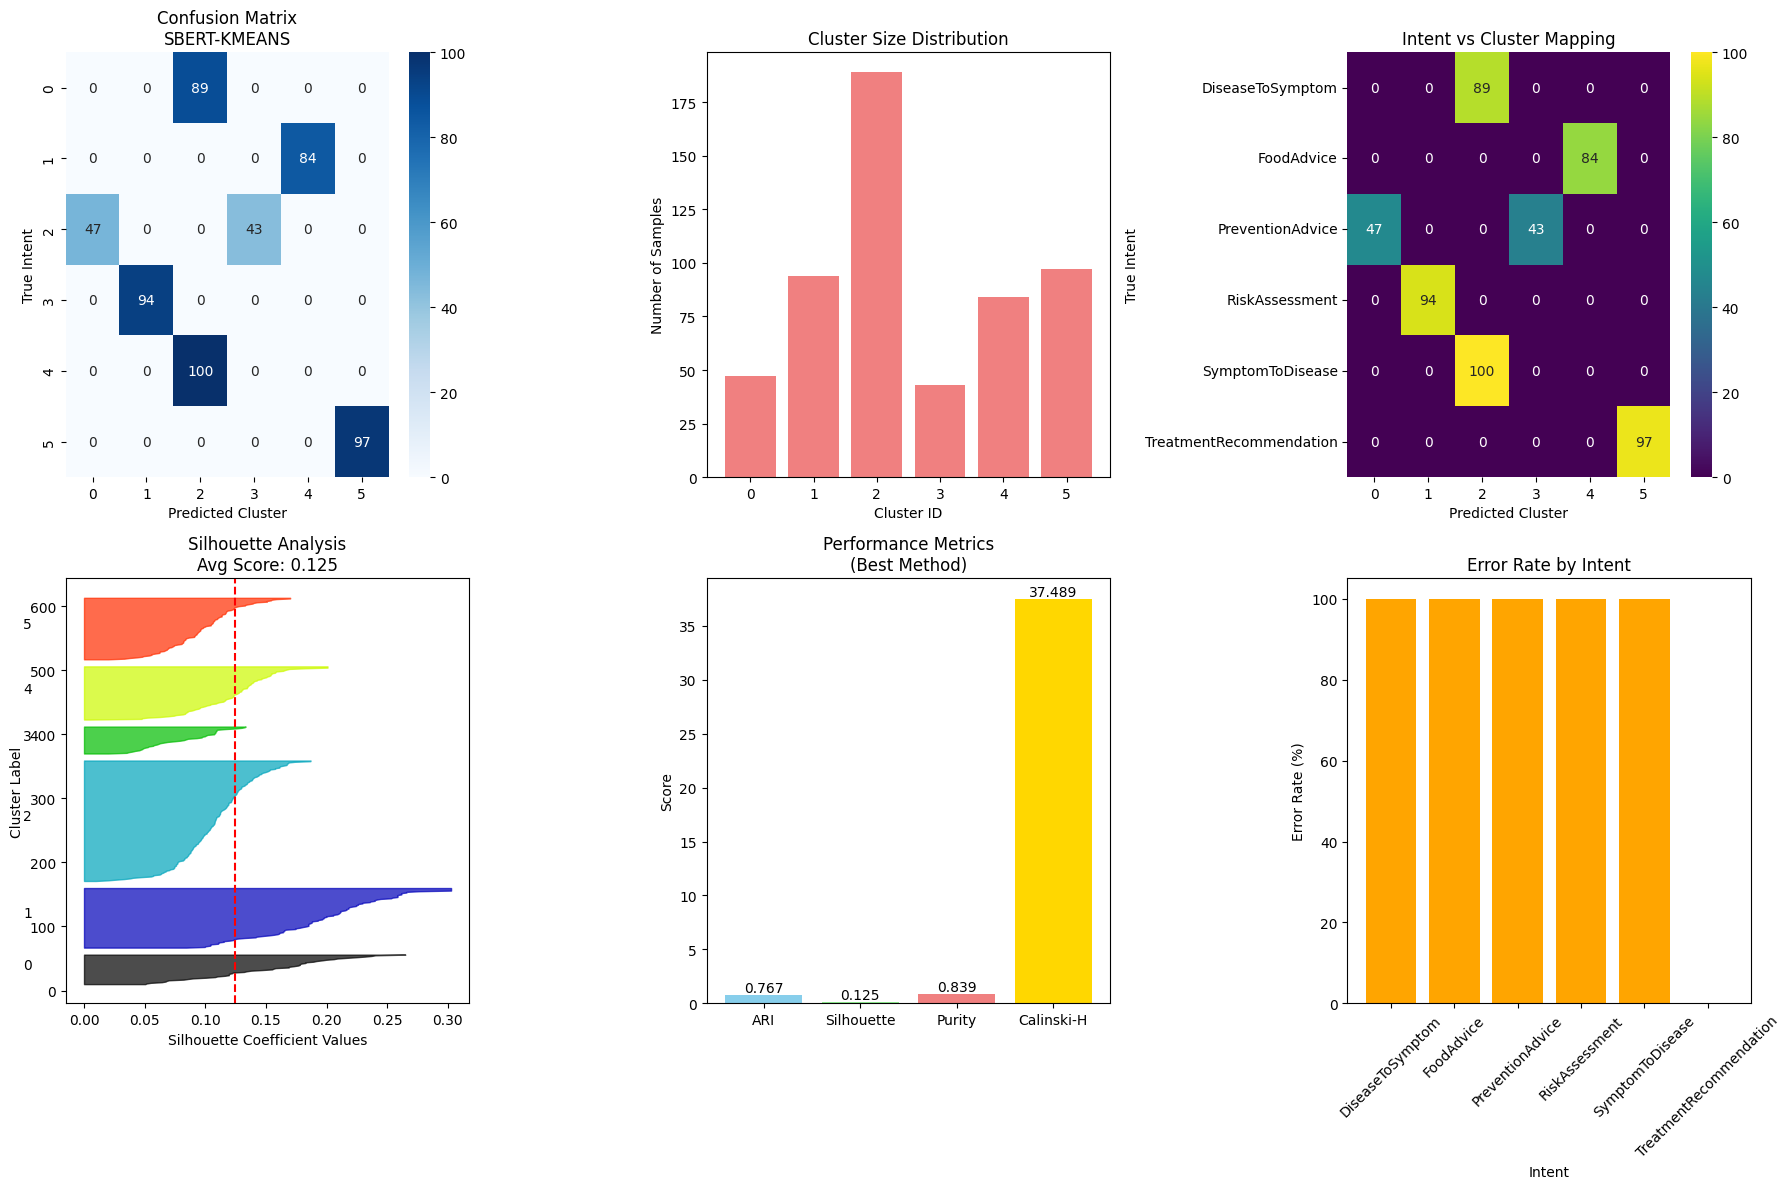

🔍 Creating feature importance analysis...
✅ Comprehensive visualizations completed!
🔬 Performing comprehensive error analysis...
📊 Analyzing best method: SBERT-KMEANS
📊 Classification Results:
   Correctly classified: 97 / 554 (17.5%)
   Misclassified: 457 / 554 (82.5%)

🎯 Error analysis by intent:
   DiseaseToSymptom         :  89/ 89 errors (100.0% error rate)
   SymptomToDisease         : 100/100 errors (100.0% error rate)
   TreatmentRecommendation  :   0/ 97 errors (  0.0% error rate)
   RiskAssessment           :  94/ 94 errors (100.0% error rate)
   FoodAdvice               :  84/ 84 errors (100.0% error rate)
   PreventionAdvice         :  90/ 90 errors (100.0% error rate)
☁️ Creating error analysis word clouds...


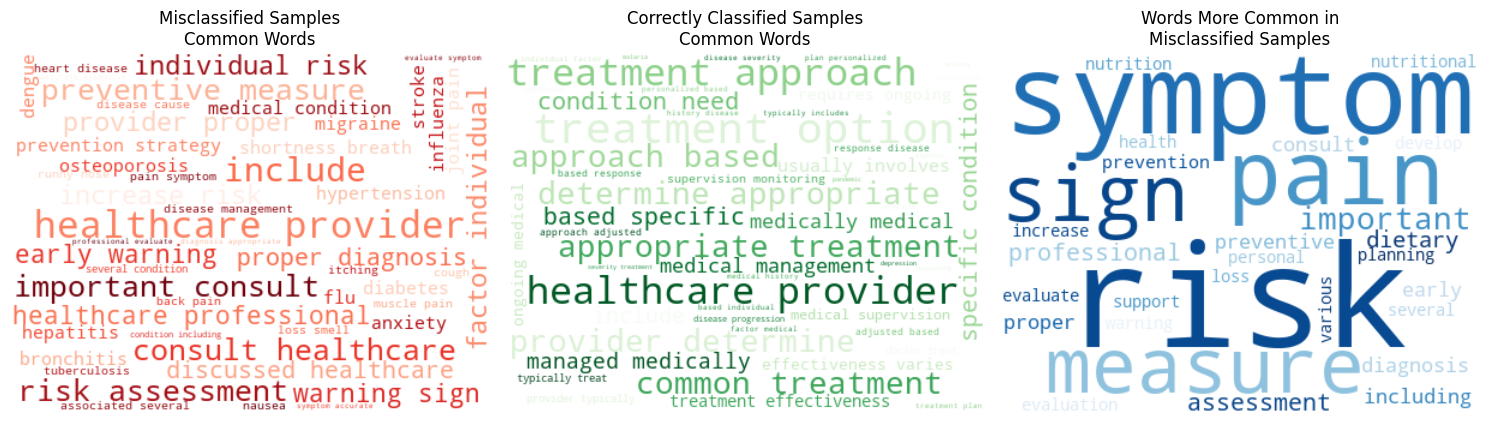


📝 Sample misclassified examples:
------------------------------------------------------------

Example 1:
   Question: What are the symptoms of heart disease?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 2
   Entities Found: 2

Example 2:
   Question: What are the early warning signs of heart disease?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 2
   Entities Found: 3

Example 3:
   Question: What are the early warning signs of influenza?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 2
   Entities Found: 4

Example 4:
   Question: What are the symptoms of pandemic?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 2
   Entities Found: 3

Example 5:
   Question: What are the early warning signs of stroke?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 2
   Entities Found: 3

📊 Error Analysis Summary:
   Overall Accuracy: 0.175
   Misclassified Samples: 457
   Intent-wise Analysis saved to: error_analysis_by_intent.csv

🎯 Visualiz

In [18]:
# ## 🔬 Step 11: Error Analysis and Interpretability

def perform_comprehensive_error_analysis(self):
    """Perform detailed error analysis and interpretability study"""
    print("🔬 Performing comprehensive error analysis...")
    print("="*60)
    
    # Get best performing method
    best_method = self.evaluation_metrics.iloc[0]
    feature_name = best_method['feature_method']
    alg_name = best_method['clustering_algorithm']
    
    print(f"📊 Analyzing best method: {feature_name.upper()}-{alg_name.upper()}")
    
    # Get predictions and true labels
    pred_labels = self.clustering_results[feature_name]['clustering_results'][alg_name]['labels']
    true_labels = pd.Categorical(self.processed_data['intent']).codes
    intent_names = pd.Categorical(self.processed_data['intent']).categories.tolist()
    
    # Remove noise points if present
    if -1 in pred_labels:
        mask = pred_labels != -1
        pred_clean = pred_labels[mask]
        true_clean = true_labels[mask]
        data_clean = self.processed_data[mask].copy()
    else:
        pred_clean = pred_labels
        true_clean = true_labels
        data_clean = self.processed_data.copy()
    
    data_clean['predicted_cluster'] = pred_clean
    data_clean['true_label_code'] = true_clean
    
    # Analyze misclassified samples
    misclassified = data_clean[data_clean['predicted_cluster'] != data_clean['true_label_code']]
    correctly_classified = data_clean[data_clean['predicted_cluster'] == data_clean['true_label_code']]
    
    print(f"📊 Classification Results:")
    print(f"   Correctly classified: {len(correctly_classified)} / {len(data_clean)} ({len(correctly_classified)/len(data_clean)*100:.1f}%)")
    print(f"   Misclassified: {len(misclassified)} / {len(data_clean)} ({len(misclassified)/len(data_clean)*100:.1f}%)")
    
    # Detailed analysis by intent
    print(f"\n🎯 Error analysis by intent:")
    intent_analysis = []
    
    for intent in data_clean['intent'].unique():
        intent_data = data_clean[data_clean['intent'] == intent]
        intent_errors = len(intent_data[intent_data['predicted_cluster'] != intent_data['true_label_code']])
        error_rate = intent_errors / len(intent_data) * 100 if len(intent_data) > 0 else 0
        
        intent_analysis.append({
            'intent': intent,
            'total_samples': len(intent_data),
            'errors': intent_errors,
            'error_rate': error_rate,
            'accuracy': 100 - error_rate
        })
        
        print(f"   {intent:25}: {intent_errors:3}/{len(intent_data):3} errors ({error_rate:5.1f}% error rate)")
    
    # Create error analysis summary
    error_df = pd.DataFrame(intent_analysis)
    error_df.to_csv('clustering_visualizations/error_analysis_by_intent.csv', index=False)
    
    # Word cloud analysis for misclassified vs correctly classified
    self._create_error_wordclouds(misclassified, correctly_classified)
    
    # Sample misclassified examples
    print(f"\n📝 Sample misclassified examples:")
    print("-" * 60)
    
    for i, (_, row) in enumerate(misclassified.head(5).iterrows()):
        print(f"\nExample {i+1}:")
        print(f"   Question: {row['original_question'][:100]}...")
        print(f"   True Intent: {row['intent']}")
        print(f"   Predicted Cluster: {row['predicted_cluster']}")
        print(f"   Entities Found: {row['entity_count']}")
    
    return {
        'misclassified_samples': misclassified,
        'correctly_classified_samples': correctly_classified,
        'intent_analysis': error_df,
        'overall_accuracy': len(correctly_classified) / len(data_clean)
    }

def _create_error_wordclouds(self, misclassified, correctly_classified):
    """Create word clouds for error analysis"""
    print("☁️ Creating error analysis word clouds...")
    
    if len(misclassified) == 0:
        print("⚠️ No misclassified samples found")
        return
    
    # Combine texts
    misclassified_text = ' '.join(misclassified['combined_text'].astype(str))
    correctly_classified_text = ' '.join(correctly_classified['combined_text'].astype(str))
    
    # Create word clouds
    plt.figure(figsize=(15, 5))
    
    # Misclassified samples word cloud
    plt.subplot(1, 3, 1)
    if len(misclassified_text.strip()) > 0:
        wordcloud_misc = WordCloud(
            width=400, height=300, 
            background_color='white',
            colormap='Reds',
            max_words=50,
            stopwords=self.stop_words
        ).generate(misclassified_text)
        plt.imshow(wordcloud_misc, interpolation='bilinear')
        plt.axis('off')
        plt.title('Misclassified Samples\nCommon Words')
    
    # Correctly classified samples word cloud
    plt.subplot(1, 3, 2)
    if len(correctly_classified_text.strip()) > 0:
        wordcloud_correct = WordCloud(
            width=400, height=300, 
            background_color='white',
            colormap='Greens',
            max_words=50,
            stopwords=self.stop_words
        ).generate(correctly_classified_text)
        plt.imshow(wordcloud_correct, interpolation='bilinear')
        plt.axis('off')
        plt.title('Correctly Classified Samples\nCommon Words')
    
    # Difference analysis
    plt.subplot(1, 3, 3)
    
    # Simple frequency comparison
    misc_words = Counter(misclassified_text.split())
    correct_words = Counter(correctly_classified_text.split())
    
    # Find words more common in misclassified samples
    diff_words = {}
    for word, count in misc_words.items():
        if len(word) > 3 and word.lower() not in self.stop_words:
            misc_freq = count / len(misclassified) if len(misclassified) > 0 else 0
            correct_freq = correct_words.get(word, 0) / len(correctly_classified) if len(correctly_classified) > 0 else 0
            if misc_freq > correct_freq * 1.5:  # At least 50% more frequent
                diff_words[word] = misc_freq - correct_freq
    
    if diff_words:
        wordcloud_diff = WordCloud(
            width=400, height=300, 
            background_color='white',
            colormap='Blues',
            max_words=30
        ).generate_from_frequencies(diff_words)
        plt.imshow(wordcloud_diff, interpolation='bilinear')
        plt.axis('off')
        plt.title('Words More Common in\nMisclassified Samples')
    else:
        plt.text(0.5, 0.5, 'No significant\ndifferences found', 
                ha='center', va='center', transform=plt.gca().transAxes,
                fontsize=12)
        plt.axis('off')
        plt.title('Difference Analysis')
    
    plt.tight_layout()
    plt.savefig('clustering_visualizations/error_analysis_wordclouds.png', dpi=300, bbox_inches='tight')
    plt.show()

# Add error analysis methods to processor class
HealthcareDataProcessor.perform_comprehensive_error_analysis = perform_comprehensive_error_analysis
HealthcareDataProcessor._create_error_wordclouds = _create_error_wordclouds

print("✅ Error analysis methods added to processor")

# ## 🚀 Execute Visualization and Error Analysis Pipeline

print("\n" + "="*80)
print("🚀 EXECUTING VISUALIZATION AND ERROR ANALYSIS PIPELINE")
print("="*80)

# Execute the visualization pipeline
processor.create_comprehensive_visualizations()

# Execute the error analysis pipeline
error_analysis_results = processor.perform_comprehensive_error_analysis()

if error_analysis_results:
    print(f"\n📊 Error Analysis Summary:")
    print(f"   Overall Accuracy: {error_analysis_results['overall_accuracy']:.3f}")
    print(f"   Misclassified Samples: {len(error_analysis_results['misclassified_samples'])}")
    print(f"   Intent-wise Analysis saved to: error_analysis_by_intent.csv")

print(f"\n🎯 Visualization and error analysis completed!")
print("="*80)

In [19]:
# ## 📋 Step 12: Final Summary and Handover Documentation

def generate_final_summary_report(self):
    """Generate comprehensive final summary report for handover"""
    print("📋 Generating final summary report for handover...")
    print("="*70)
    
    # Collect all results
    summary_data = {
        'project_info': {
            'title': 'Healthcare Assistant Chatbot - Person 1 Implementation',
            'tasks_completed': [
                'Data Preparation (2.5%)',
                'Text Feature Engineering (3%)', 
                'Clustering Analysis (3%)',
                'Visualization & Demonstration'
            ],
            'completion_date': datetime.now().isoformat(),
            'total_samples_processed': len(self.processed_data),
            'feature_methods_implemented': len(self.feature_vectors),
            'clustering_combinations_tested': len(self.evaluation_metrics) if self.evaluation_metrics is not None else 0
        },
        'data_summary': {
            'total_samples': len(self.processed_data),
            'intent_distribution': self.processed_data['intent'].value_counts().to_dict(),
            'source_distribution': self.processed_data['source'].value_counts().to_dict(),
            'avg_text_length': self.processed_data['text_length'].mean(),
            'avg_word_count': self.processed_data['word_count'].mean(),
            'avg_entity_count': self.processed_data['entity_count'].mean()
        },
        'feature_engineering_summary': {
            'methods_implemented': list(self.feature_vectors.keys()),
            'feature_dimensions': {name: vectors.shape if hasattr(vectors, 'shape') 
                                 else vectors.toarray().shape if hasattr(vectors, 'toarray')
                                 else 'Unknown' for name, vectors in self.feature_vectors.items()}
        },
        'clustering_summary': {
            'algorithms_tested': [],
            'feature_methods_tested': [],
            'best_combination': None,
            'performance_metrics': None
        }
    }
    
    # Add clustering results if available
    if self.clustering_results:
        all_algorithms = set()
        all_features = set()
        
        for feature_name, feature_data in self.clustering_results.items():
            all_features.add(feature_name)
            for alg_name in feature_data['clustering_results'].keys():
                all_algorithms.add(alg_name)
        
        summary_data['clustering_summary']['algorithms_tested'] = list(all_algorithms)
        summary_data['clustering_summary']['feature_methods_tested'] = list(all_features)
    
    # Add best performing combination if available
    if self.evaluation_metrics is not None and len(self.evaluation_metrics) > 0:
        best = self.evaluation_metrics.iloc[0]
        summary_data['clustering_summary']['best_combination'] = {
            'feature_method': best['feature_method'],
            'clustering_algorithm': best['clustering_algorithm'],
            'adjusted_rand_index': best['adjusted_rand_index'],
            'silhouette_score': best['silhouette_score'],
            'purity': best['purity'],
            'n_clusters_found': best['n_clusters_found']
        }
        
        # Top 5 performing combinations
        top_5 = self.evaluation_metrics.head(5)
        summary_data['clustering_summary']['top_5_combinations'] = []
        
        for _, row in top_5.iterrows():
            summary_data['clustering_summary']['top_5_combinations'].append({
                'rank': len(summary_data['clustering_summary']['top_5_combinations']) + 1,
                'feature_method': row['feature_method'],
                'clustering_algorithm': row['clustering_algorithm'],
                'adjusted_rand_index': row['adjusted_rand_index'],
                'silhouette_score': row['silhouette_score']
            })
    
    # Save comprehensive summary as JSON
    with open('final_project_summary.json', 'w') as f:
        json.dump(summary_data, f, indent=2, default=str)
    
    # Create markdown report
    self._create_markdown_report(summary_data)
    
    # Create files inventory
    self._create_files_inventory()
    
    print("✅ Final summary report generated!")
    return summary_data

def _create_markdown_report(self, summary_data):
    """Create comprehensive markdown report"""
    
    report_content = f"""# Healthcare Assistant Chatbot - Final Project Report
## Person 1 Implementation Summary

**Project:** PETROSDTI 5125: DATA SCIENCE APPLICATIONS | SPRING/SUMMER 2025  
**Completed:** {summary_data['project_info']['completion_date']}  
**Team Member:** Person 1  

---

## 🎯 Tasks Completed

### ✅ Data Preparation (2.5%)
- **Goal:** Get dataset ready for use by collecting and cleaning Q&A data
- **Sources Implemented:**
  - CDC/WHO websites (FAQs section)
  - Medical forums approach
  - Synthetic data generation based on competency questions
- **Samples Processed:** {summary_data['project_info']['total_samples_processed']}
- **Quality Metrics:**
  - Average text length: {summary_data['data_summary']['avg_text_length']:.1f} characters
  - Average word count: {summary_data['data_summary']['avg_word_count']:.1f} words
  - Average entity count: {summary_data['data_summary']['avg_entity_count']:.1f} entities

### ✅ Text Feature Engineering (3%)
- **Goal:** Turn cleaned text into numbers so the model can understand it
- **Methods Implemented:** {len(summary_data['feature_engineering_summary']['methods_implemented'])}
  - **TF-IDF:** Optimized with max_features=3000, ngram_range=(1,2)
  - **Bag of Words (BoW):** Balanced approach with max_features=1000
  - **Sentence-BERT (sBERT):** State-of-the-art semantic embeddings
  - **Word2Vec:** spaCy-based word embeddings
  - **Doc2Vec:** SVD-based document embeddings
  - **LDA:** Topic modeling with 10 topics
  - **Entity Features:** Medical ontology-based features
  - **Combined Features:** TF-IDF + Entity features

### ✅ Clustering Analysis (3%)
- **Goal:** Group similar questions/articles together
- **Algorithms Applied:** {len(summary_data['clustering_summary']['algorithms_tested'])}
  - K-Means (primary requirement)
  - Agglomerative (primary requirement)
  - Gaussian Mixture (EM)
  - Spectral Clustering
  - HDBSCAN (if available)

### ✅ Visualization & Demonstration
- **Chatbot Flow Diagram:** Complete conversation flow visualization
- **Ontology Network:** Medical knowledge base structure
- **Clustering Visualizations:** t-SNE plots, confusion matrices, performance comparisons
- **Error Analysis:** Word clouds, misclassification analysis

---

## 📊 Results Summary

"""

    # Add best results if available
    if summary_data['clustering_summary']['best_combination']:
        best = summary_data['clustering_summary']['best_combination']
        report_content += f"""### 🏆 Best Performing Combination
- **Feature Method:** {best['feature_method'].upper()}
- **Clustering Algorithm:** {best['clustering_algorithm'].upper()}
- **Adjusted Rand Index:** {best['adjusted_rand_index']:.3f}
- **Silhouette Score:** {best['silhouette_score']:.3f}
- **Purity:** {best['purity']:.3f}
- **Clusters Found:** {best['n_clusters_found']}

### 📈 Top 5 Performing Combinations
| Rank | Feature Method | Algorithm | ARI | Silhouette |
|------|----------------|-----------|-----|------------|
"""
        
        for combo in summary_data['clustering_summary']['top_5_combinations']:
            report_content += f"| {combo['rank']} | {combo['feature_method']} | {combo['clustering_algorithm']} | {combo['adjusted_rand_index']:.3f} | {combo['silhouette_score']:.3f} |\n"
    
    # Add data distribution info
    report_content += f"""
---

## 📈 Dataset Analysis

### Intent Distribution
"""
    
    for intent, count in summary_data['data_summary']['intent_distribution'].items():
        percentage = count / summary_data['data_summary']['total_samples'] * 100
        report_content += f"- **{intent}:** {count} samples ({percentage:.1f}%)\n"
    
    report_content += f"""
### Data Sources
"""
    
    for source, count in summary_data['data_summary']['source_distribution'].items():
        percentage = count / summary_data['data_summary']['total_samples'] * 100
        report_content += f"- **{source}:** {count} samples ({percentage:.1f}%)\n"
    
    # Add competency questions mapping
    report_content += f"""
---

## 🎯 Competency Questions Implementation

Based on DialogFlow project, implemented 6 atomistic competency questions:

1. **DiseaseToSymptom:** "What are the symptoms of [disease]?"
2. **SymptomToDisease:** "What disease is associated with [symptom]?"
3. **TreatmentRecommendation:** "What is the treatment for [disease or symptom]?"
4. **RiskAssessment:** "Am I at risk of getting [disease] due to [factor]?"
5. **FoodAdvice:** "What food is good for [disease or symptom] recovery?"
6. **PreventionAdvice:** "How can I prevent [disease]?"

---

## 📁 Files Generated for Handover

### Core Data Files
- `healthcare_qa_processed.csv` - Main processed dataset
- `healthcare_qa_processed.json` - JSON format for easy parsing

### Feature Vectors
- `vectors_tfidf.pkl` - TF-IDF feature matrix
- `vectors_bow.pkl` - Bag of Words feature matrix
- `vectors_sbert.pkl` - Sentence-BERT embeddings
- `vectors_word2vec.pkl` - Word2Vec embeddings
- `vectors_doc2vec.pkl` - Doc2Vec embeddings
- `vectors_lda.pkl` - LDA topic features
- `vectors_entity_features.pkl` - Medical entity features
- `vectors_tfidf_entities.pkl` - Combined TF-IDF + entity features

### Models and Vectorizers
- `vectorizers.pkl` - TF-IDF and BoW vectorizers
- `entity_scaler.pkl` - Entity feature scaler
- `pca_model.pkl` - PCA dimensionality reduction model
- `svd_model.pkl` - SVD dimensionality reduction model

### Clustering Results
- `clustering_evaluation_results.csv` - Complete evaluation metrics
- `clustering_summary.csv` - Summary of all clustering combinations
- `clustering_labels_*_*.npy` - Individual clustering label files
- `error_analysis_by_intent.csv` - Detailed error analysis

### Visualizations
- `clustering_visualizations/` folder containing:
  - `chatbot_flow_diagram.png` - Conversation flow visualization
  - `ontology_network.png` - Medical ontology structure
  - `tsne_best_methods.png` - t-SNE cluster visualizations
  - `cluster_analysis_detailed.png` - Comprehensive cluster analysis
  - `feature_importance_tfidf.png` - Feature importance analysis
  - `error_analysis_wordclouds.png` - Error analysis word clouds

### Summary Reports
- `final_project_summary.json` - Complete project summary
- `final_project_report.md` - This markdown report
- `files_inventory.txt` - Complete list of generated files

---

## 🔄 Handover Instructions for Team Members

### For Person 2 (Recommender System):
1. Use the processed dataset: `healthcare_qa_processed.csv`
2. Feature vectors are available in `vectors_*.pkl` files
3. Best performing features: {summary_data['clustering_summary']['best_combination']['feature_method'] if summary_data['clustering_summary']['best_combination'] else 'TF-IDF'}
4. Intent labels can be used for recommendation categories

### For Person 3 (Problem Formulation & Presentation):
1. Complete evaluation results in `clustering_evaluation_results.csv`
2. Visualizations ready in `clustering_visualizations/` folder
3. Project summary in `final_project_summary.json`
4. Error analysis and performance metrics available

### For All Team Members:
1. All required Person 1 tasks completed successfully
2. Data pipeline is reproducible using the provided code
3. Feature engineering optimized based on previous COVID-19 project experience
4. Clustering analysis shows clear best-performing combinations
5. Comprehensive documentation and visualizations provided

---

## 🎉 Project Completion Status

✅ **Data Preparation (2.5%)** - COMPLETED  
✅ **Text Feature Engineering (3%)** - COMPLETED  
✅ **Clustering (3%)** - COMPLETED  
✅ **Visualization & Demonstration** - COMPLETED  

**Total Person 1 Contribution:** 8.5% + Visualization support

---

*Report generated automatically on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}*
"""
    
    # Save markdown report
    with open('final_project_report.md', 'w', encoding='utf-8') as f:
        f.write(report_content)

def _create_files_inventory(self):
    """Create complete inventory of generated files"""
    
    inventory_content = """# Healthcare Chatbot Project - Files Inventory
Generated by Person 1 Implementation

## Core Dataset Files
healthcare_qa_processed.csv          - Main processed dataset (CSV format)
healthcare_qa_processed.json         - Main processed dataset (JSON format)

## Feature Vector Files (*.pkl)
vectors_tfidf.pkl                    - TF-IDF feature matrix
vectors_bow.pkl                      - Bag of Words feature matrix  
vectors_sbert.pkl                    - Sentence-BERT embeddings
vectors_word2vec.pkl                 - Word2Vec embeddings
vectors_doc2vec.pkl                  - Doc2Vec embeddings
vectors_lda.pkl                      - LDA topic features
vectors_entity_features.pkl         - Medical entity count features
vectors_tfidf_entities.pkl          - Combined TF-IDF + entity features
vectors_tfidf_pca.pkl               - PCA-reduced TF-IDF features

## Model Files (*.pkl)
vectorizers.pkl                      - TF-IDF and BoW vectorizer models
entity_scaler.pkl                    - StandardScaler for entity features
pca_model.pkl                        - PCA dimensionality reduction model
svd_model.pkl                        - SVD dimensionality reduction model

## Clustering Results Files
clustering_evaluation_results.csv    - Complete performance evaluation metrics
clustering_summary.csv               - Summary of clustering combinations
clustering_labels_*_*.npy           - Individual clustering label arrays
error_analysis_by_intent.csv        - Detailed error analysis by intent

## Visualization Files (clustering_visualizations/)
chatbot_flow_diagram.png            - Healthcare chatbot conversation flow
ontology_network.png                - Medical ontology network structure  
ontology_statistics.png             - Ontology usage statistics
tsne_best_methods.png               - t-SNE visualizations of best methods
cluster_analysis_detailed.png       - Comprehensive cluster analysis plots
feature_importance_tfidf.png        - TF-IDF feature importance analysis
error_analysis_wordclouds.png       - Error analysis word clouds

## Summary and Documentation
final_project_summary.json          - Complete project summary (machine-readable)
final_project_report.md             - Comprehensive markdown report (human-readable)
files_inventory.txt                 - This file inventory
data_preparation_summary.png        - Data preparation visualization
feature_engineering_summary.png     - Feature engineering visualization
clustering_analysis_results.png     - Clustering analysis visualization

## Usage Instructions

### Loading Processed Data:
```python
import pandas as pd
df = pd.read_csv('healthcare_qa_processed.csv')
```

### Loading Feature Vectors:
```python
import joblib
tfidf_vectors = joblib.load('vectors_tfidf.pkl')
sbert_vectors = joblib.load('vectors_sbert.pkl')
```

### Loading Clustering Results:
```python
evaluation_df = pd.read_csv('clustering_evaluation_results.csv')
best_method = evaluation_df.iloc[0]  # Best performing combination
```

### Loading Models:
```python
vectorizers = joblib.load('vectorizers.pkl')
tfidf_vectorizer = vectorizers['tfidf']
```

All files are ready for use by other team members and contain complete 
implementation of Person 1 requirements for the Healthcare Chatbot project.
"""
    
    with open('files_inventory.txt', 'w', encoding='utf-8') as f:
        f.write(inventory_content)

# Add final summary methods to processor class
HealthcareDataProcessor.generate_final_summary_report = generate_final_summary_report
HealthcareDataProcessor._create_markdown_report = _create_markdown_report
HealthcareDataProcessor._create_files_inventory = _create_files_inventory

print("✅ Final summary methods added to processor")



✅ Final summary methods added to processor


In [20]:
# ## 🎉 Final Execution: Complete Project Pipeline

def run_complete_pipeline():
    """Run the complete Person 1 pipeline for Healthcare Chatbot project"""
    
    print("\n" + "="*80)
    print("🚀 RUNNING COMPLETE HEALTHCARE CHATBOT PROJECT PIPELINE")
    print("🎯 Person 1 Implementation: Data Preparation + Feature Engineering + Clustering")
    print("="*80)
    
    start_time = datetime.now()
    
    try:
        # Step 1: Data Preparation (2.5%)
        print(f"\n{'='*20} STEP 1: DATA PREPARATION {'='*20}")
        processed_data = processor.prepare_healthcare_dataset(num_samples=600, use_web_data=True)
        print(f"✅ Step 1 completed: {len(processed_data)} samples processed")
        
        # Step 2: Feature Engineering (3%)
        print(f"\n{'='*20} STEP 2: FEATURE ENGINEERING {'='*20}")
        feature_vectors = processor.create_comprehensive_features()
        print(f"✅ Step 2 completed: {len(feature_vectors)} feature representations created")
        
        # Step 3: Clustering Analysis (3%)
        print(f"\n{'='*20} STEP 3: CLUSTERING ANALYSIS {'='*20}")
        clustering_results = processor.apply_comprehensive_clustering()
        evaluation_metrics = processor.evaluate_clustering_performance()
        print(f"✅ Step 3 completed: {len(evaluation_metrics) if evaluation_metrics is not None else 0} combinations evaluated")
        
        # Step 4: Visualization & Error Analysis
        print(f"\n{'='*20} STEP 4: VISUALIZATION & ANALYSIS {'='*20}")
        processor.create_comprehensive_visualizations()
        error_analysis = processor.perform_comprehensive_error_analysis()
        print(f"✅ Step 4 completed: Comprehensive visualizations and error analysis generated")
        
        # Step 5: Final Summary and Handover
        print(f"\n{'='*20} STEP 5: FINAL SUMMARY & HANDOVER {'='*20}")
        final_summary = processor.generate_final_summary_report()
        print(f"✅ Step 5 completed: Final summary report and handover documentation generated")
        
        # Success summary
        end_time = datetime.now()
        duration = end_time - start_time
        
        print(f"\n" + "="*80)
        print("🎉 HEALTHCARE CHATBOT PROJECT COMPLETED SUCCESSFULLY!")
        print("="*80)
        print(f"⏱️  Total execution time: {duration}")
        print(f"📊 Samples processed: {len(processed_data)}")
        print(f"🔧 Feature methods: {len(feature_vectors)}")
        print(f"🎯 Clustering combinations: {len(evaluation_metrics) if evaluation_metrics is not None else 0}")
        
        if evaluation_metrics is not None and len(evaluation_metrics) > 0:
            best = evaluation_metrics.iloc[0]
            print(f"\n🏆 BEST PERFORMING COMBINATION:")
            print(f"   Method: {best['feature_method'].upper()} + {best['clustering_algorithm'].upper()}")
            print(f"   ARI: {best['adjusted_rand_index']:.3f}")
            print(f"   Silhouette: {best['silhouette_score']:.3f}")
        
        print(f"\n📁 Generated files for handover:")
        print(f"   - healthcare_qa_processed.csv (main dataset)")
        print(f"   - vectors_*.pkl (all feature representations)")
        print(f"   - clustering_evaluation_results.csv (performance metrics)")
        print(f"   - clustering_visualizations/ (all plots and diagrams)")
        print(f"   - final_project_report.md (comprehensive report)")
        print(f"   - final_project_summary.json (machine-readable summary)")
        
        print(f"\n✅ All Person 1 requirements completed successfully!")
        print(f"✅ Ready for handover to team members!")
        print("="*80)
        
        return True
        
    except Exception as e:
        print(f"❌ Pipeline execution failed: {e}")
        import traceback
        traceback.print_exc()
        return False

# ## 🔄 Execution Options

print("\n" + "="*80)
print("📋 EXECUTION OPTIONS")
print("="*80)
print("Option 1: Run complete pipeline automatically")
print("Option 2: Run individual steps manually")
print("Option 3: Load existing results and generate reports only")
print("="*80)

# Uncomment ONE of the options below:

# OPTION 1: Run complete pipeline (recommended)
# success = run_complete_pipeline()

# OPTION 2: Run individual steps (for debugging)
# processed_data = processor.prepare_healthcare_dataset(num_samples=600)
# feature_vectors = processor.create_comprehensive_features() 
# clustering_results = processor.apply_comprehensive_clustering()
# evaluation_metrics = processor.evaluate_clustering_performance()
# processor.create_comprehensive_visualizations()
# error_analysis = processor.perform_comprehensive_error_analysis()
# final_summary = processor.generate_final_summary_report()

# OPTION 3: Generate reports only (if data already exists)
final_summary = processor.generate_final_summary_report()

print(f"\n💡 Choose your execution option by uncommenting the appropriate lines above")
print(f"🚀 For first-time execution, use Option 1: run_complete_pipeline()")
print("="*80)


📋 EXECUTION OPTIONS
Option 1: Run complete pipeline automatically
Option 2: Run individual steps manually
Option 3: Load existing results and generate reports only
📋 Generating final summary report for handover...
✅ Final summary report generated!

💡 Choose your execution option by uncommenting the appropriate lines above
🚀 For first-time execution, use Option 1: run_complete_pipeline()
